## Import thư viện và thiết lập môi trường

Cell này dùng để khởi tạo các thư viện cần thiết cho toàn bộ pipeline:
- xử lý và phân tích dữ liệu,
- trực quan hóa,
- tiền xử lý và giảm chiều dữ liệu,
- huấn luyện mô hình học máy (SVM, MLP, Random Forest),
- đánh giá mô hình bằng các chỉ số và đường cong phổ biến.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve
)
from IPython.display import display

## Nạp và kiểm tra dữ liệu ban đầu

Cell này dùng để đọc dữ liệu từ file CSV và kiểm tra nhanh cấu trúc tập dữ liệu, bao gồm vài dòng đầu, số lượng mẫu – số thuộc tính và thông tin kiểu dữ liệu, nhằm đảm bảo dữ liệu được load đúng trước khi tiền xử lý.

In [2]:
df = pd.read_csv("classData.csv")
print(df.head())
print(df.shape)
print(df.info())

   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  
(7861, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null

## Tạo nhãn FaultType từ các cột A–B–C–G

Cell này thực hiện ánh xạ tổ hợp giá trị của các cột **A, B, C, G** sang nhãn lỗi tương ứng, từ đó tạo ra cột nhãn **FaultType** dùng cho bài toán phân loại.  
Cuối cùng, phân bố số lượng mẫu của từng loại lỗi được hiển thị để kiểm tra mức độ cân bằng của dữ liệu.

Mã hóa nhãn lỗi (G, C, B, A → FaultType)

[G C B A]

[0 0 0 0] - No Fault

[1 0 0 1] - LG   (A – Ground)

[0 1 1 0] - LL   (B – C)

[1 0 1 1] - LLG  (A, B – Ground)

[0 1 1 1] - LLL  (A, B, C)

[1 1 1 1] - LLLG (A, B, C – Ground)

In [3]:
mapping = {
    (0,0,0,0): "NoFault",
    (1,0,0,1): "LG",
    (0,1,1,0): "LL",
    (1,0,1,1): "LLG",
    (0,1,1,1): "LLL",
    (1,1,1,1): "LLLG"
}

df["FaultType"] = df[["G","C","B","A"]].apply(lambda r: mapping[tuple(r)], axis=1)

print(df["FaultType"].value_counts())

FaultType
NoFault    2365
LLG        1134
LLLG       1133
LG         1129
LLL        1096
LL         1004
Name: count, dtype: int64


# Bước 1 – Khám phá dữ liệu (EDA)

## Thống kê mô tả dữ liệu

Cell này hiển thị các thống kê cơ bản của các thuộc tính số (mean, std, min, max, quartiles), giúp quan sát nhanh phân bố dữ liệu và phát hiện các giá trị bất thường trước khi thực hiện tiền xử lý.

In [4]:
print(df.describe())

                 G            C            B            A           Ia  \
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000   
mean      0.432006     0.411271     0.555527     0.571429    13.721194   
std       0.495387     0.492095     0.496939     0.494903   464.741671   
min       0.000000     0.000000     0.000000     0.000000  -883.542316   
25%       0.000000     0.000000     0.000000     0.000000  -119.802518   
50%       0.000000     0.000000     1.000000     1.000000     2.042805   
75%       1.000000     1.000000     1.000000     1.000000   227.246377   
max       1.000000     1.000000     1.000000     1.000000   885.738571   

                Ib           Ic           Va           Vb           Vc  
count  7861.000000  7861.000000  7861.000000  7861.000000  7861.000000  
mean    -44.845268    34.392394    -0.007667     0.001152     0.006515  
std     439.269195   371.107412     0.289150     0.313437     0.307897  
min    -900.526951  -883.357762    -0.620

## Trực quan hóa phân phối đặc trưng

Cell này vẽ histogram cho các đặc trưng dòng điện và điện áp nhằm quan sát phân bố giá trị của từng biến, từ đó đánh giá mức độ lệch, độ trải rộng và sự khác biệt giữa các đặc trưng trước khi chuẩn hóa dữ liệu.


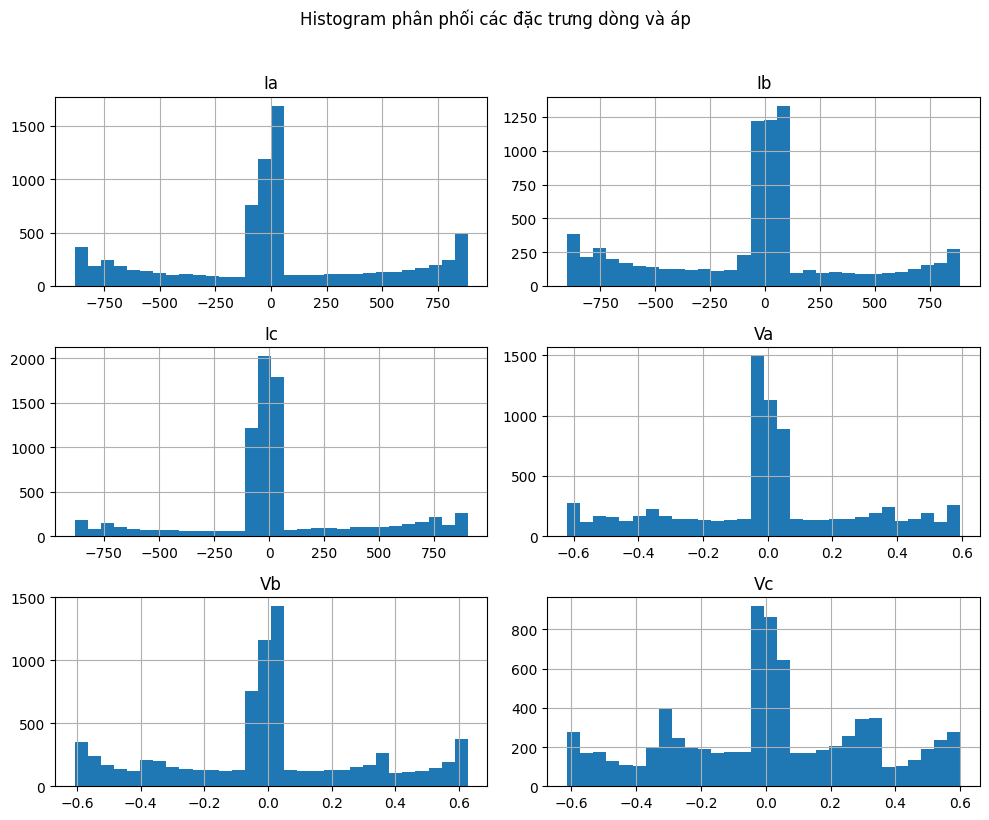

In [5]:
features = ["Ia","Ib","Ic","Va","Vb","Vc"]
df[features].hist(figsize=(10, 8), bins=30)
plt.suptitle("Histogram phân phối các đặc trưng dòng và áp", y=1.02)
plt.tight_layout()
plt.show()

## Boxplot đặc trưng theo từng loại lỗi

Cell này sử dụng boxplot để so sánh phân bố các đặc trưng dòng và áp theo từng nhãn lỗi, giúp đánh giá mức độ phân tách giữa các lớp cũng như phát hiện outlier trong dữ liệ


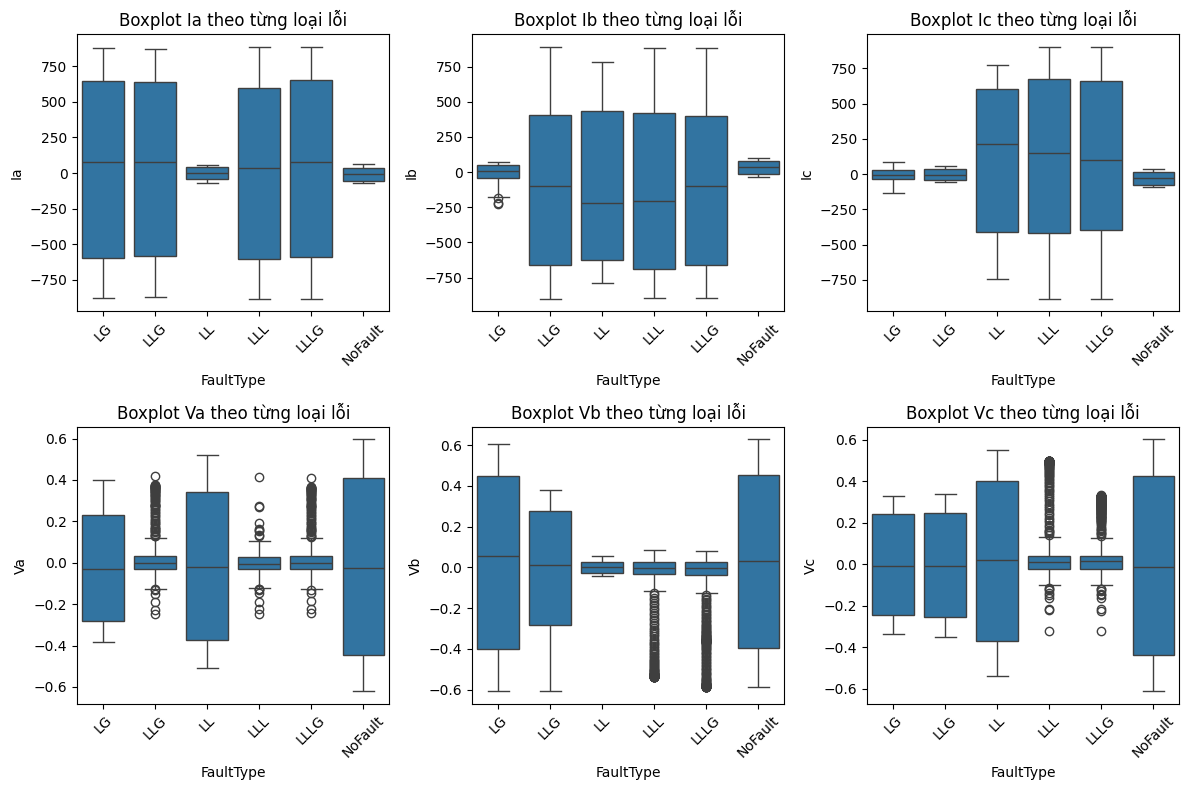

In [6]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="FaultType", y=col)
    plt.title(f"Boxplot {col} theo từng loại lỗi")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Giá trị trung bình của đặc trưng theo loại lỗi

Cell này tính giá trị trung bình của các đặc trưng dòng điện và điện áp cho từng loại lỗi, giúp quan sát sự khác biệt đặc trưng giữa các lớp và hỗ trợ đánh giá khả năng phân biệt của dữ liệu.


In [7]:
print(df.groupby("FaultType")[features].mean().round(3))

               Ia       Ib       Ic     Va     Vb     Vc
FaultType                                               
LG         35.626    3.188   -3.361 -0.021  0.026 -0.004
LL         -1.587 -102.565  106.674 -0.015  0.000  0.014
LLG        35.926  -93.011   -3.189  0.011 -0.007 -0.004
LLL         5.459 -113.142  109.773 -0.001 -0.031  0.032
LLLG       35.647  -91.402  105.602  0.010 -0.041  0.030
NoFault    -7.559   33.778  -29.298 -0.019  0.029 -0.010


## Phân tích tương quan giữa các đặc trưng

Cell này vẽ heatmap ma trận tương quan giữa các đặc trưng dòng và áp, giúp đánh giá mức độ phụ thuộc tuyến tính và phát hiện các đặc trưng có tương quan cao trước khi huấn luyện mô hình.


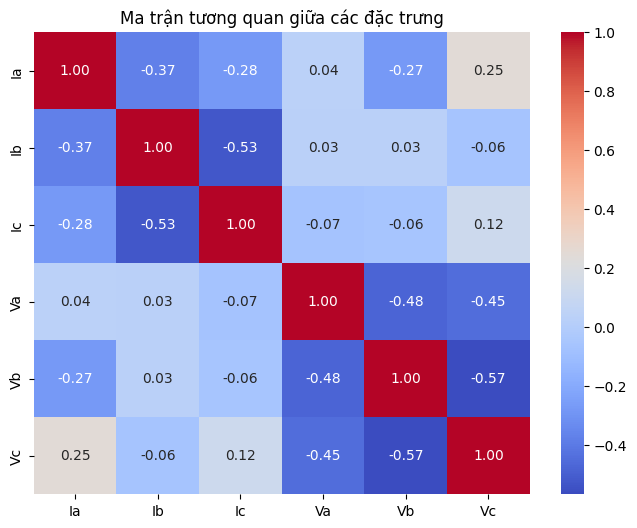

In [8]:
plt.figure(figsize=(8, 6))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan giữa các đặc trưng")
plt.show()

## Phân bố nhãn lỗi

Cell này trực quan hóa số lượng mẫu của từng loại lỗi nhằm đánh giá mức độ cân bằng của tập dữ liệu, từ đó xem xét ảnh hưởng tiềm năng đến quá trình huấn luyện và đánh giá mô hình.


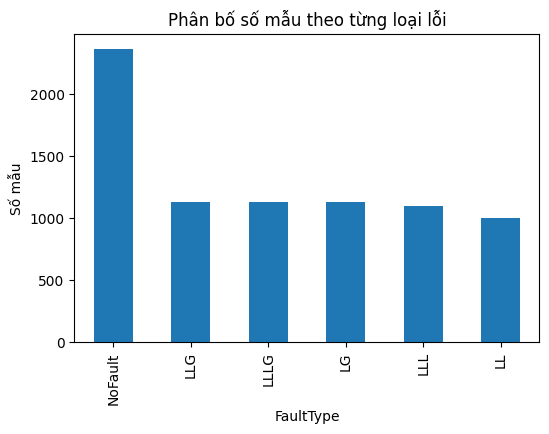

In [9]:
plt.figure(figsize=(6,4))
df["FaultType"].value_counts().plot(kind="bar")
plt.title("Phân bố số mẫu theo từng loại lỗi")
plt.ylabel("Số mẫu")
plt.show()

## Giảm chiều dữ liệu và trực quan hóa bằng PCA

Cell này chuẩn hóa dữ liệu, sau đó áp dụng PCA để giảm số chiều xuống còn 2 thành phần chính nhằm trực quan hóa sự phân bố và khả năng phân tách giữa các loại lỗi trong không gian đặc trưng.
Tỷ lệ phương sai được giải thích cho biết mức độ thông tin được giữ lại bởi hai thành phần chính.


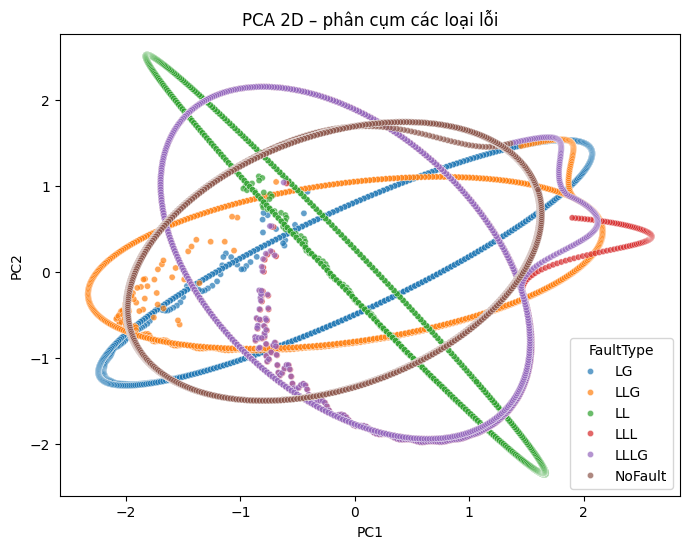

Variance explained by PC1, PC2: [0.30741346 0.25698704]


In [10]:
X = df[features].values
y = df["FaultType"].values

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "FaultType": y
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="FaultType", s=20, alpha=0.7)
plt.title("PCA 2D – phân cụm các loại lỗi")
plt.show()

print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_)

## Trực quan hóa mối quan hệ cặp đặc trưng

Cell này sử dụng pairplot để quan sát mối quan hệ giữa từng cặp đặc trưng theo từng loại lỗi, giúp đánh giá khả năng phân tách lớp và phát hiện các mẫu phân bố chồng lấn trong không gian đặc trưng.


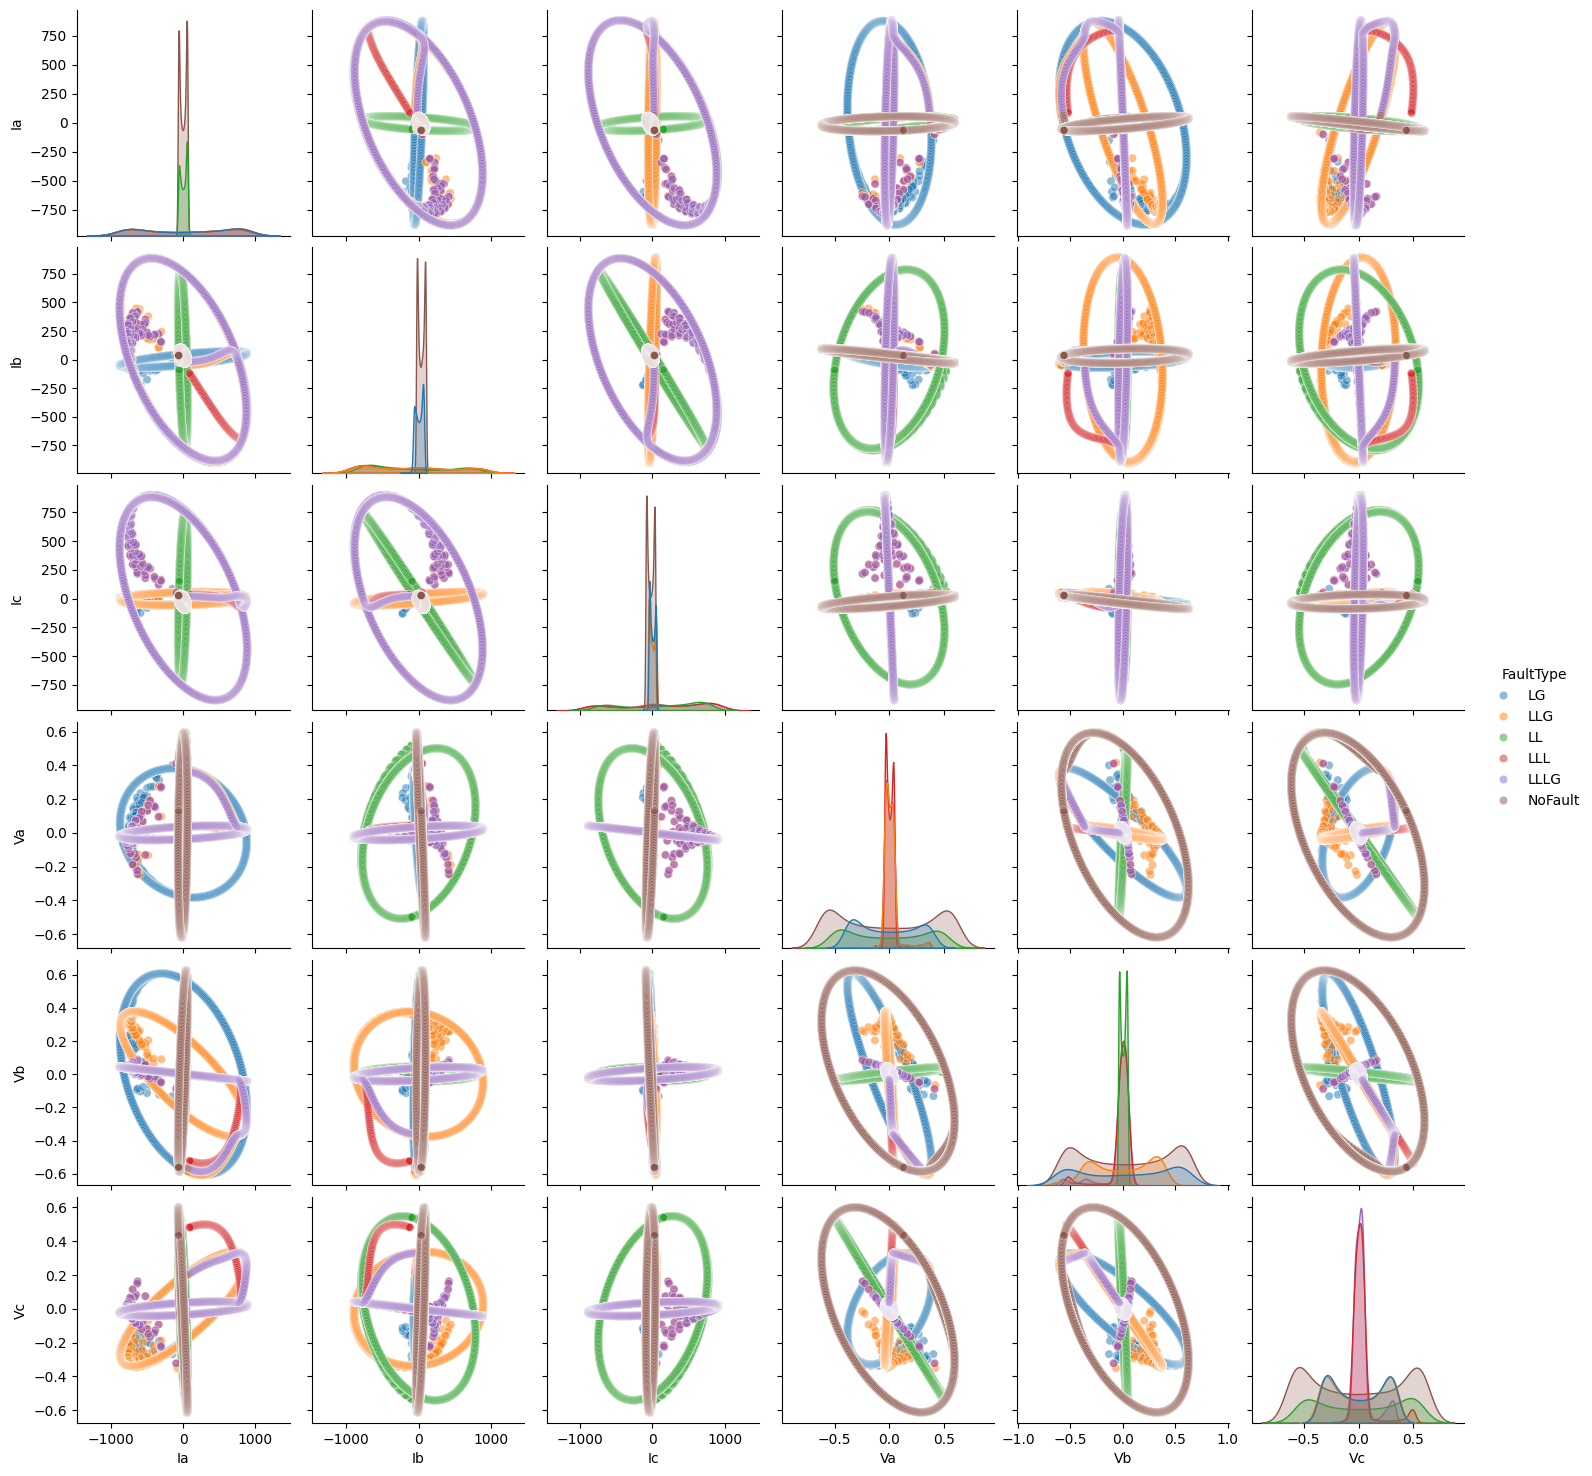

In [11]:
sns.pairplot(df, vars=features, hue="FaultType", plot_kws={'alpha':0.5})
plt.show()

## Violin plot phân bố đặc trưng theo nhãn lỗi

Cell này sử dụng violin plot để thể hiện đầy đủ phân bố giá trị của các đặc trưng dòng và áp theo từng loại lỗi, giúp quan sát đồng thời mật độ phân bố và sự khác biệt giữa các lớp.


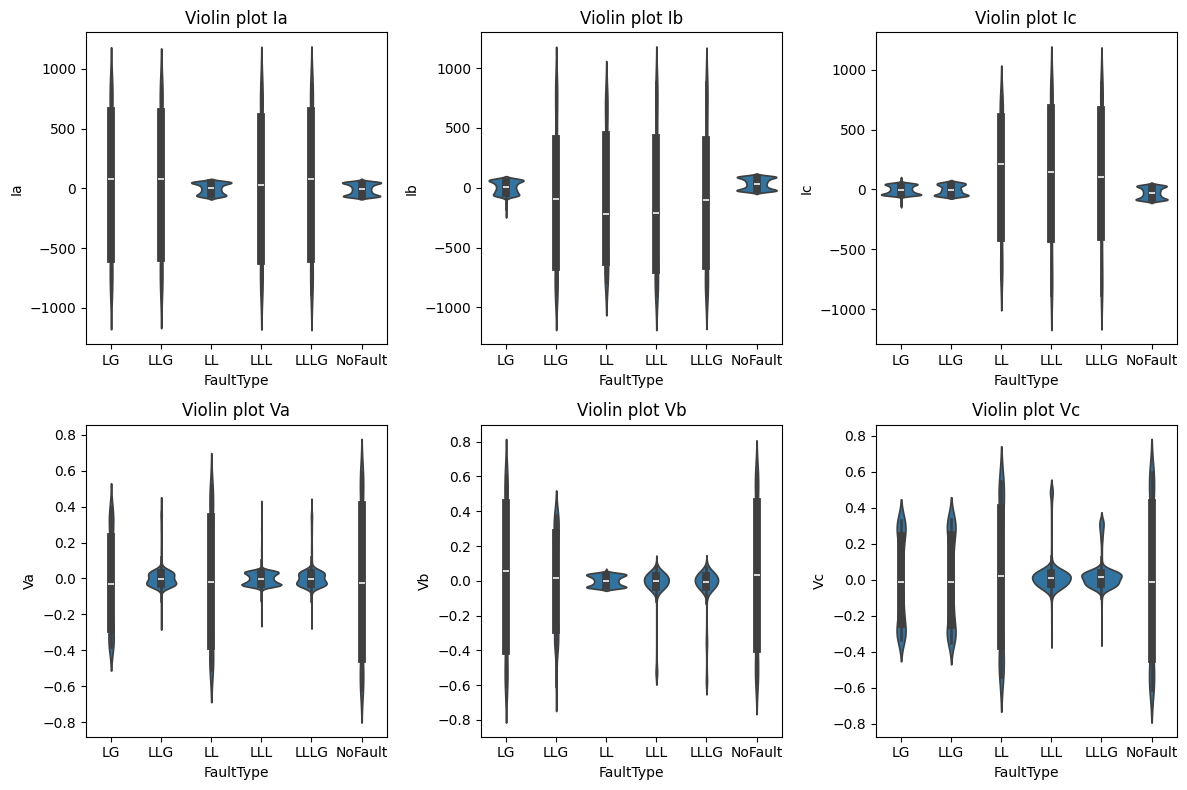

In [12]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.violinplot(data=df, x="FaultType", y=col)
    plt.title(f"Violin plot {col}")
plt.tight_layout()
plt.show()

## Scatter matrix các đặc trưng (style R&D)

Cell này vẽ scatter matrix để quan sát mối quan hệ giữa các đặc trưng ở dạng cặp, đồng thời thể hiện phân bố của từng đặc trưng trên đường chéo, hỗ trợ đánh giá khả năng phân tách và tương quan trong dữ liệu.


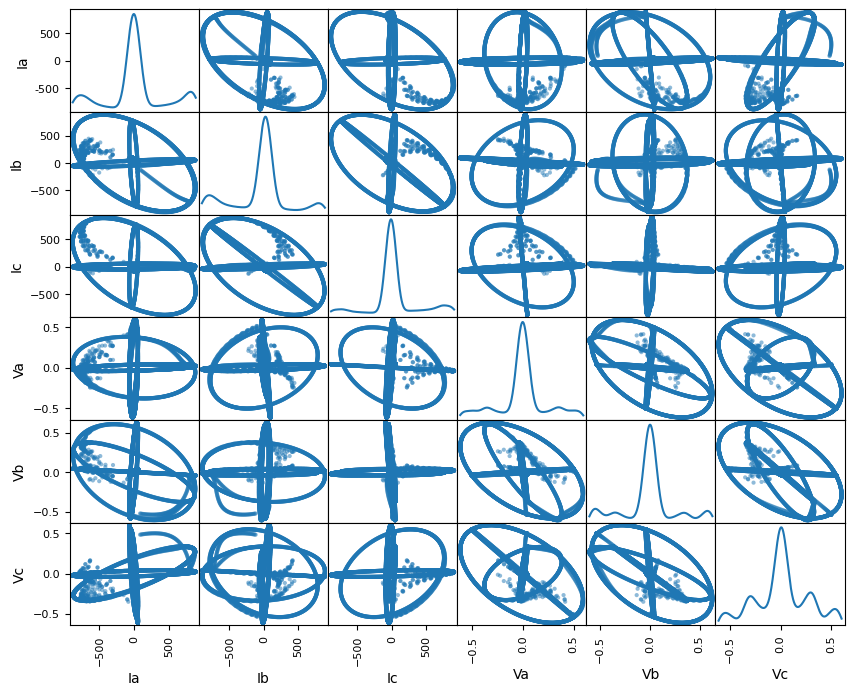

In [13]:
scatter_matrix(df[features], figsize=(10, 8), diagonal="kde")
plt.show()

## Phân tích phương sai tích lũy bằng PCA (Scree Plot)

Cell này áp dụng PCA với đầy đủ số thành phần và vẽ scree plot để quan sát tỷ lệ phương sai tích lũy theo số lượng thành phần chính, từ đó hỗ trợ lựa chọn số chiều phù hợp cho mô hình.


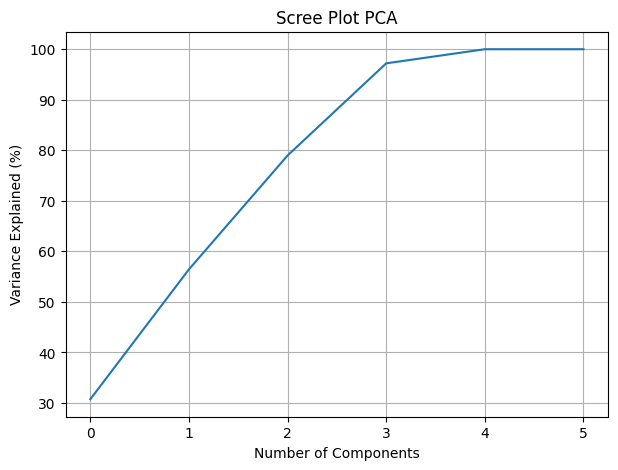

In [14]:
pca_full = PCA(n_components=6)
pca_full.fit(X_scaled)

plt.figure(figsize=(7,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_)*100)
plt.xlabel("Number of Components")
plt.ylabel("Variance Explained (%)")
plt.title("Scree Plot PCA")
plt.grid()
plt.show()

## Phân tích hệ số tải (PCA Loadings)

Cell này hiển thị hệ số tải của các đặc trưng trên hai thành phần chính đầu tiên, giúp đánh giá mức độ đóng góp và ảnh hưởng của từng đặc trưng vào không gian PCA.


In [15]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=features
)
print(loadings)

         PC1       PC2
Ia  0.441255  0.211411
Ib -0.391744  0.400873
Ic  0.217742 -0.545718
Va  0.002984  0.556030
Vb -0.546208 -0.423479
Vc  0.553233 -0.091076


# Bước 2 – Tiền xử lý

## Chia tập huấn luyện và kiểm tra

Cell này chia dữ liệu thành tập train và test theo tỷ lệ 80/20, đồng thời sử dụng stratify để đảm bảo phân bố các loại lỗi được giữ nguyên giữa hai tập, giúp việc đánh giá mô hình khách quan hơn.


In [16]:
X = df[features].values
y = df["FaultType"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # giữ tỷ lệ class
)

## Chuẩn hóa dữ liệu đặc trưng

Cell này chuẩn hóa các đặc trưng bằng StandardScaler dựa trên tập huấn luyện và áp dụng cùng phép biến đổi cho tập kiểm tra, nhằm đưa các đặc trưng về cùng thang đo trước khi huấn luyện mô hình.


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Xử lý outliers

In [18]:
def cap_outliers(df_in, cols, k=1.5):
    df_out = df_in.copy()
    for col in cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - k * IQR
        upper = Q3 + k * IQR
        df_out[col] = df_out[col].clip(lower=lower, upper=upper)
    return df_out

# nếu muốn dùng:
# df_capped = cap_outliers(df, features)

# Bước 3 – Huấn luyện mô hình SVM

## Huấn luyện mô hình SVM (Baseline)

Cell này huấn luyện mô hình SVM với kernel RBF và các tham số cơ bản làm baseline, đồng thời bật probability để phục vụ cho các bước đánh giá nâng cao như ROC và Precision–Recall.


In [19]:
# ----- Train SVM Baseline -----
svm_baseline = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_baseline.fit(X_train_scaled, y_train)

y_pred_base = svm_baseline.predict(X_test_scaled)
y_proba_base = svm_baseline.predict_proba(X_test_scaled)

## Tối ưu siêu tham số SVM bằng GridSearchCV

Cell này sử dụng GridSearchCV để tìm bộ siêu tham số tối ưu cho SVM dựa trên cross-validation, với tiêu chí đánh giá là F1-score có trọng số nhằm cải thiện hiệu năng trên các lớp mất cân bằng.


In [20]:
params = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(class_weight='balanced', probability=True), params, cv=3, scoring='f1_weighted')
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)

Best params: {'C': 50, 'gamma': 'scale', 'kernel': 'rbf'}


## Huấn luyện SVM với siêu tham số tối ưu

Cell này khởi tạo và huấn luyện lại mô hình SVM sử dụng các siêu tham số tốt nhất tìm được từ GridSearchCV, sau đó sinh dự đoán và xác suất để phục vụ cho bước đánh giá chi tiết.


In [21]:
best_C = grid.best_params_['C']
best_gamma = grid.best_params_['gamma']

svm_opt = SVC(
    kernel="rbf",
    C=best_C,
    gamma=best_gamma,
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm_opt.fit(X_train_scaled, y_train)

y_pred_opt = svm_opt.predict(X_test_scaled)
y_proba_opt = svm_opt.predict_proba(X_test_scaled)

# Bước 4 - Đánh giá mô hình SVM

## Đánh giá mô hình bằng các chỉ số phân loại

Cell này định nghĩa hàm tính các chỉ số đánh giá chính (Accuracy, Precision, Recall, F1 theo macro) và so sánh hiệu năng giữa mô hình SVM baseline và mô hình đã tối ưu siêu tham số.


In [22]:
def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro"),
        "recall_macro": recall_score(y_true, y_pred, average="macro"),
        "f1_macro": f1_score(y_true, y_pred, average="macro")
    }

metrics_base = calc_metrics(y_test, y_pred_base)
metrics_opt  = calc_metrics(y_test, y_pred_opt)

print("Baseline Metrics:", metrics_base)
print("Optimized Metrics:", metrics_opt)

Baseline Metrics: {'accuracy': 0.8397965670692944, 'precision_macro': 0.8098948887993447, 'recall_macro': 0.8132306504855947, 'f1_macro': 0.8071199092111816}
Optimized Metrics: {'accuracy': 0.8474253019707565, 'precision_macro': 0.8214854747384736, 'recall_macro': 0.821413820804052, 'f1_macro': 0.8181631976187692}


## So sánh hiệu năng SVM Baseline và SVM tối ưu

Cell này tổng hợp các chỉ số đánh giá của hai mô hình SVM vào một bảng so sánh, giúp quan sát trực quan mức độ cải thiện hiệu năng sau khi tối ưu siêu tham số.


In [23]:
comparison_df = pd.DataFrame({
    "Metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    "Baseline": [
        metrics_base["accuracy"],
        metrics_base["precision_macro"],
        metrics_base["recall_macro"],
        metrics_base["f1_macro"]
    ],
    "Optimized": [
        metrics_opt["accuracy"],
        metrics_opt["precision_macro"],
        metrics_opt["recall_macro"],
        metrics_opt["f1_macro"]
    ]
})

comparison_df

,Metric,Baseline,Optimized
0,accuracy,0.839797,0.847425
1,precision_macro,0.809895,0.821485
2,recall_macro,0.813231,0.821414
3,f1_macro,0.807120,0.818163


## So sánh trực quan hiệu năng SVM

Cell này sử dụng biểu đồ cột để so sánh trực quan các chỉ số đánh giá chính giữa mô hình SVM baseline và mô hình đã tối ưu, giúp dễ dàng nhận thấy mức độ cải thiện hiệu năng của mô hình sau quá trình tinh chỉnh.


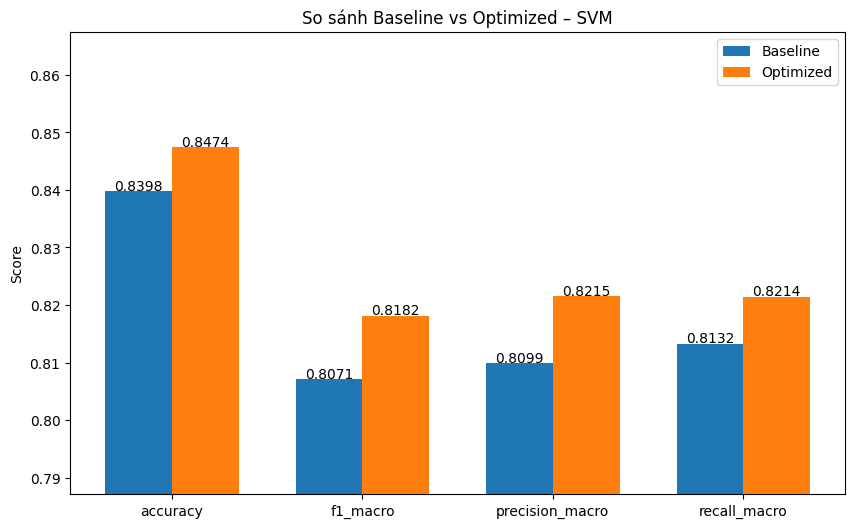

In [24]:
labels = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

baseline_scores = [
    metrics_base["accuracy"],
    metrics_base["f1_macro"],
    metrics_base["precision_macro"],
    metrics_base["recall_macro"]
]

opt_scores = [
    metrics_opt["accuracy"],
    metrics_opt["f1_macro"],
    metrics_opt["precision_macro"],
    metrics_opt["recall_macro"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_scores, width, label="Baseline")
plt.bar(x + width/2, opt_scores, width, label="Optimized")

for i, v in enumerate(baseline_scores):
    plt.text(x[i] - width/2, v + 0.0002, f"{v:.4f}", ha='center')

for i, v in enumerate(opt_scores):
    plt.text(x[i] + width/2, v + 0.0002, f"{v:.4f}", ha='center')

plt.ylim( min(baseline_scores + opt_scores) - 0.02,
          max(baseline_scores + opt_scores) + 0.02 )
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("So sánh Baseline vs Optimized – SVM")
plt.legend()
plt.show()

## Learning Curve của mô hình SVM

Cell này vẽ learning curve để quan sát sự thay đổi độ chính xác trên tập huấn luyện và tập validation theo kích thước dữ liệu huấn luyện, từ đó đánh giá khả năng học, mức độ overfitting hoặc underfitting của mô hình SVM.


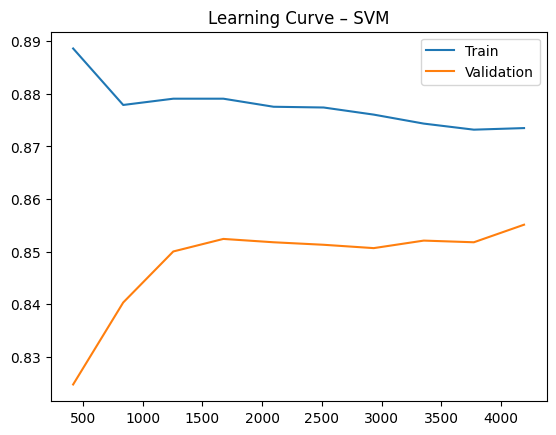

In [25]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_opt, X_train_scaled, y_train, cv=3,
    scoring="accuracy", train_sizes=np.linspace(0.1,1.0,10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve – SVM")
plt.legend()
plt.show()

## Đánh giá chi tiết mô hình SVM Baseline

Cell này in độ chính xác tổng thể và báo cáo phân loại chi tiết cho mô hình SVM baseline, đồng thời trực quan hóa ma trận nhầm lẫn để phân tích các lỗi dự đoán giữa các loại lỗi khác nhau.


Accuracy (SVM Baseline): 0.8397965670692944

Classification report (SVM Baseline):
               precision    recall  f1-score   support

          LG       0.97      1.00      0.98       226
          LL       1.00      0.99      0.99       201
         LLG       0.97      0.97      0.97       227
         LLL       0.47      0.62      0.54       219
        LLLG       0.46      0.30      0.37       227
     NoFault       0.99      1.00      0.99       473

    accuracy                           0.84      1573
   macro avg       0.81      0.81      0.81      1573
weighted avg       0.84      0.84      0.83      1573



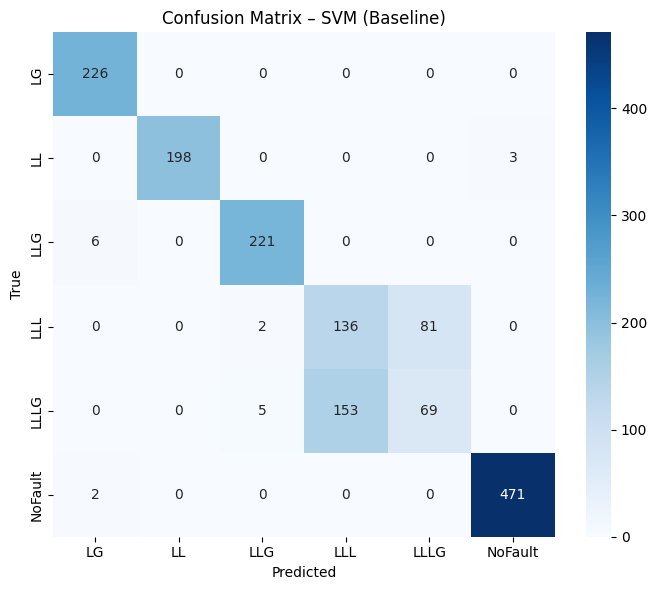

In [26]:
print("Accuracy (SVM Baseline):", accuracy_score(y_test, y_pred_base))
print("\nClassification report (SVM Baseline):\n",
      classification_report(y_test, y_pred_base))

cm_base = confusion_matrix(y_test, y_pred_base, labels=svm_baseline.classes_)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_baseline.classes_,
    yticklabels=svm_baseline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – SVM (Baseline)")
plt.tight_layout()
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – SVM Baseline

Cell này chuẩn hóa ma trận nhầm lẫn theo từng lớp thực để thể hiện tỷ lệ dự đoán đúng và sai, giúp đánh giá rõ hơn hiệu năng của mô hình SVM baseline trên từng loại lỗi.


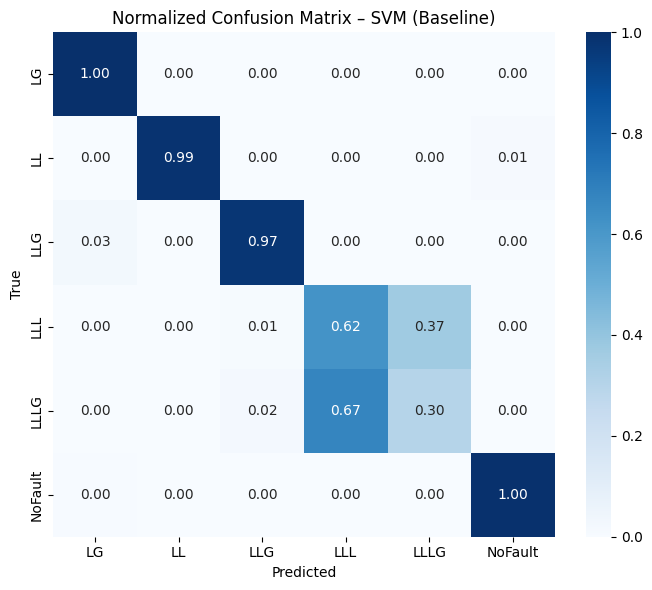

In [27]:
cm_base_norm = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_base_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=svm_baseline.classes_,
    yticklabels=svm_baseline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix – SVM (Baseline)")
plt.tight_layout()
plt.show()

## Đánh giá mô hình SVM sau khi tối ưu

Cell này in độ chính xác và báo cáo phân loại chi tiết của mô hình SVM đã được tối ưu siêu tham số, nhằm so sánh trực tiếp hiệu năng với mô hình baseline.


In [28]:
# Sử dụng dự đoán optimized model (đã tính trước)
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("\nClassification report:\n", classification_report(y_test, y_pred_opt))

Accuracy: 0.8474253019707565

Classification report:
               precision    recall  f1-score   support

          LG       0.97      1.00      0.99       226
          LL       1.00      1.00      1.00       201
         LLG       1.00      0.97      0.99       227
         LLL       0.48      0.61      0.53       219
        LLLG       0.48      0.35      0.40       227
     NoFault       1.00      1.00      1.00       473

    accuracy                           0.85      1573
   macro avg       0.82      0.82      0.82      1573
weighted avg       0.85      0.85      0.84      1573



## Ma trận nhầm lẫn – SVM tối ưu

Cell này trực quan hóa ma trận nhầm lẫn của mô hình SVM đã tối ưu, giúp phân tích chi tiết các trường hợp dự đoán đúng và nhầm lẫn giữa các loại lỗi.


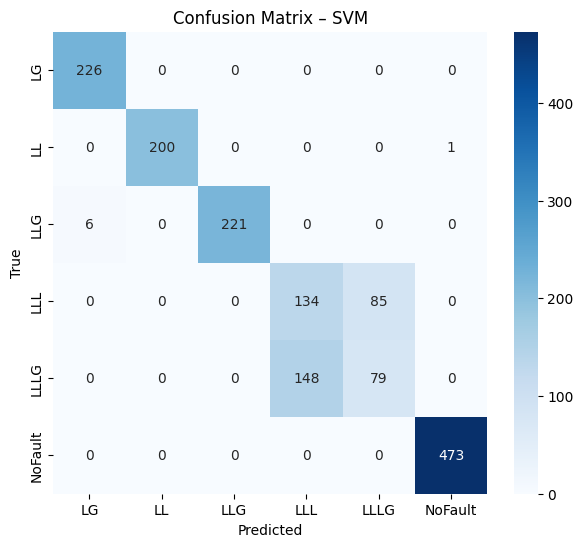

In [29]:
cm = confusion_matrix(y_test, y_pred_opt, labels=svm_opt.classes_)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=svm_opt.classes_,
            yticklabels=svm_opt.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – SVM")
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – SVM tối ưu

Cell này chuẩn hóa ma trận nhầm lẫn của mô hình SVM theo từng lớp thực, giúp đánh giá tỷ lệ dự đoán đúng và sai cho từng loại lỗi một cách trực quan hơn.


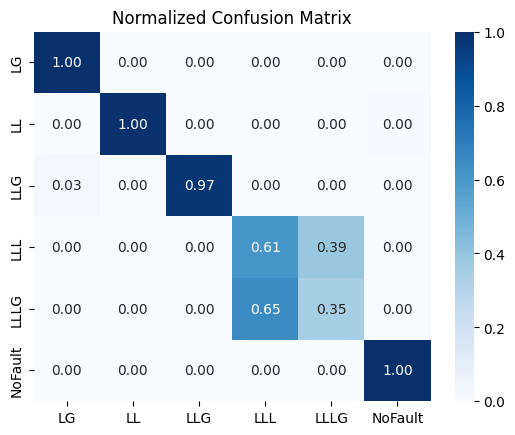

In [30]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=svm_opt.classes_, yticklabels=svm_opt.classes_)
plt.title("Normalized Confusion Matrix")
plt.show()

## Đánh giá ROC–AUC cho bài toán đa lớp

Cell này chuyển đổi nhãn sang dạng nhị phân và tính ROC–AUC cho mô hình SVM đã tối ưu theo chiến lược one-vs-rest, sử dụng cả trung bình macro và weighted để đánh giá tổng thể khả năng phân biệt giữa các lớp.


In [31]:
# Binarize nhãn
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

y_proba_opt = svm_opt.predict_proba(X_test_scaled)

# ROC-AUC cho mô hình optimized
roc_auc_macro = roc_auc_score(y_test_bin, y_proba_opt, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_test_bin, y_proba_opt, multi_class="ovr", average="weighted")

print("ROC-AUC macro:", roc_auc_macro)
print("ROC-AUC weighted:", roc_auc_weighted)

ROC-AUC macro: 0.973058408268494
ROC-AUC weighted: 0.9770856413632487


## Precision–Recall Curve cho từng lớp

Cell này vẽ đường Precision–Recall theo chiến lược one-vs-rest cho từng loại lỗi, giúp đánh giá chi tiết khả năng cân bằng giữa precision và recall của mô hình SVM trên từng lớp.


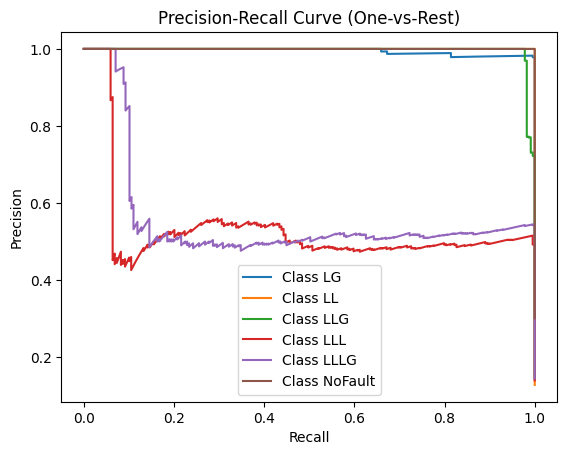

In [32]:
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_opt[:, i])
    plt.plot(recall, precision, label=f"Class {cls}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall Curve (One-vs-Rest)")
plt.show()

## Minh họa dự đoán trên một số mẫu kiểm tra
Xem 10 mẫu test ngẫu nhiên (có đúng/sai)

Cell này chọn ngẫu nhiên một số mẫu từ tập test, thực hiện dự đoán bằng mô hình SVM đã tối ưu và hiển thị kết quả so sánh giữa nhãn thực và nhãn dự đoán, giúp minh họa trực quan độ chính xác của mô hình.


In [33]:
# chọn ngẫu nhiên 10 mẫu trong test
idx = np.random.choice(len(X_test), size=10, replace=False)

X_sample = X_test[idx]
y_true = y_test[idx]

X_sample_scaled = scaler.transform(X_sample)
y_pred = svm_opt.predict(X_sample_scaled)

result = pd.DataFrame(X_sample, columns=features)
result["True"] = y_true
result["Pred"] = y_pred
result["Correct"] = (result["True"] == result["Pred"])

result

,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
0,-291.975089,-588.285388,-57.148832,-0.037968,0.323738,-0.285770,LLG,LLG,True
1,-863.982277,351.679036,-20.536629,-0.024326,0.322003,-0.297676,LLG,LLG,True
2,53.922056,12.288933,-69.372944,0.003288,0.535855,-0.539143,NoFault,NoFault,True
3,304.701985,-26.458702,47.409056,0.334215,-0.605916,0.271701,LG,LG,True
4,-66.143346,82.411562,-19.263923,-0.366857,-0.230033,0.596890,NoFault,NoFault,True
5,877.963595,49.747593,4.449870,-0.038407,-0.239925,0.278332,LG,LG,True
6,-471.027851,-427.085714,900.284215,-0.042290,0.023832,0.018458,LLL,LLLG,False
7,-562.954432,259.312933,305.828886,0.068138,0.010010,-0.078148,LLL,LLL,True
8,-41.389546,-347.486656,391.315323,-0.503454,-0.036552,0.540006,LL,LL,True
9,540.194107,336.737591,-874.801757,0.041735,-0.027198,-0.014536,LLL,LLL,True


## In riêng các mẫu dự đoán SAI (để xem model nhầm chỗ nào)
Cell này xác định các mẫu bị mô hình SVM dự đoán sai trên tập kiểm tra và hiển thị một số mẫu tiêu biểu, giúp phân tích nguyên nhân nhầm lẫn và hiểu rõ hơn hạn chế của mô hình.

In [34]:
y_pred_all = svm_opt.predict(X_test_scaled)

wrong_idx = np.where(y_pred_all != y_test)[0]
print("Số mẫu dự đoán sai:", len(wrong_idx))

if len(wrong_idx) == 0:
    print("Không có mẫu dự đoán sai.")
else:
    show_n = min(10, len(wrong_idx)) # lấy tối đa 10 mẫu sai để xem
    pick = np.random.choice(wrong_idx, size=show_n, replace=False)

    wrong_df = pd.DataFrame(X_test[pick], columns=features)
    wrong_df["True"] = y_test[pick]
    wrong_df["Pred"] = y_pred_all[pick]

    display(wrong_df)

Số mẫu dự đoán sai: 240


,Ia,Ib,Ic,Va,Vb,Vc,True,Pred
0,-154.955140,830.596890,-675.644014,0.033463,0.005754,-0.039218,LLLG,LLL
1,-664.066841,836.911513,-170.734290,0.009909,0.030723,-0.040632,LLL,LLLG
2,-687.584244,-136.972115,824.554096,-0.038883,0.034071,0.004813,LLLG,LLL
3,192.864226,-856.007552,663.181519,-0.031974,-0.007736,0.039710,LLLG,LLL
4,-411.124902,-486.735167,900.029676,-0.035402,0.019349,0.016053,LLL,LLLG
5,-525.497721,324.896235,201.390792,-0.046330,0.025836,0.020494,LLLG,LLL
6,721.707397,80.569028,-802.276283,0.037752,-0.035544,-0.002208,LLLG,LLL
7,755.035225,-775.247354,20.209867,-0.002725,-0.035212,0.037938,LLLG,LLL
8,322.395390,551.041119,-873.438773,0.042076,-0.017015,-0.025061,LLLG,LLL
9,-451.750567,884.009981,-430.224709,0.022143,0.020205,-0.042349,LLL,LLLG



## Phân tích xác suất dự đoán Top-k
Xem TOP-3 lớp dự đoán + xác suất cho vài mẫu

Cell này hiển thị Top-3 nhãn có xác suất cao nhất cho một số mẫu kiểm tra ngẫu nhiên, giúp đánh giá mức độ tự tin của mô hình SVM và quan sát các trường hợp nhãn dự đoán cạnh tranh gần nhau.

In [35]:
idx = np.random.choice(len(X_test), size=5, replace=False)

X_sample = X_test[idx]
y_true = y_test[idx]

proba = svm_opt.predict_proba(scaler.transform(X_sample))
classes = svm_opt.classes_

rows = []
for i in range(len(idx)):
    top3 = np.argsort(proba[i])[::-1][:3]
    rows.append({
        "True": y_true[i],
        "Pred": classes[top3[0]],
        "P1": float(proba[i][top3[0]]),
        "Top2": classes[top3[1]],
        "P2": float(proba[i][top3[1]]),
        "Top3": classes[top3[2]],
        "P3": float(proba[i][top3[2]]),
    })

pd.DataFrame(rows)

,True,Pred,P1,Top2,P2,Top3,P3
0,LG,LG,0.999900,LLL,0.000087,LL,0.000012
1,LL,LL,0.999021,LLG,0.000450,LG,0.000283
2,LLLG,LLL,0.543368,LLLG,0.453809,LL,0.002062
3,LLL,LLLG,0.590815,LLL,0.406306,LG,0.001445
4,LLL,LLL,0.544760,LLLG,0.453611,LG,0.001522


## Dự đoán cho 1 input “tự nhập”
nhập 6 giá trị Ia Ib Ic Va Vb Vc

In [36]:
sample = np.array([[ 
    -151.29, -9.68, 85.80, 0.4007, -0.1329, -0.2678
]])  # thay bằng số bạn muốn

pred = svm_opt.predict(scaler.transform(sample))[0]
proba = svm_opt.predict_proba(scaler.transform(sample))[0]
top = np.argsort(proba)[::-1][:3]

print("Predicted FaultType:", pred)
print("Top-3:", [(svm_opt.classes_[i], float(proba[i])) for i in top])

Predicted FaultType: LG
Top-3: [('LG', 0.8605879275517277), ('LLLG', 0.1007021338883625), ('LLG', 0.021026058627880706)]


# Bước 5 - Huấn luyện mô hình MLP (sklearn - MLPClassifier)

## Import thư viện cho mô hình MLP (sklearn)

Cell này khởi tạo các thư viện cần thiết để xây dựng, huấn luyện và đánh giá mô hình MLPClassifier, bao gồm trực quan hóa kết quả và các chỉ số đánh giá cho bài toán phân loại đa lớp.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve
)
from IPython.display import display

## Huấn luyện mô hình MLP (Baseline)

Cell này xây dựng và huấn luyện mô hình MLPClassifier với cấu hình cơ bản làm baseline, sau đó sinh dự đoán và xác suất để phục vụ cho các bước đánh giá hiệu năng tiếp theo.


In [38]:
# ----- MLP Baseline -----
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,
    random_state=42
)

mlp_baseline.fit(X_train_scaled, y_train)

y_pred_mlp_base = mlp_baseline.predict(X_test_scaled)
y_proba_mlp_base = mlp_baseline.predict_proba(X_test_scaled)

## Tối ưu siêu tham số và huấn luyện MLP

Cell này sử dụng GridSearchCV để tìm cấu hình MLP tối ưu (số tầng ẩn, regularization và learning rate) dựa trên F1-score macro, sau đó đánh giá mô hình MLP tốt nhất trên tập kiểm tra.


In [39]:
# ----- GridSearchCV for MLP -----
mlp_param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
    "alpha": [1e-5, 1e-4, 1e-3],
    "learning_rate_init": [1e-4, 1e-3, 1e-2],
}

mlp_grid = GridSearchCV(
    MLPClassifier(
        activation="relu",
        solver="adam",
        max_iter=400,
        early_stopping=True,
        random_state=42
    ),
    mlp_param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_scaled, y_train)
print("Best params (MLP):", mlp_grid.best_params_)

# ----- MLP Optimized -----
mlp_opt = mlp_grid.best_estimator_

y_pred_mlp_opt = mlp_opt.predict(X_test_scaled)
y_proba_mlp_opt = mlp_opt.predict_proba(X_test_scaled)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params (MLP): {'alpha': 1e-05, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}


# Bước 6 - Đánh giá mô hình MLP (sklearn - MLPClassifier)

## Đánh giá hiệu năng MLP

Cell này tính và so sánh các chỉ số đánh giá chính (Accuracy, Precision, Recall, F1 theo macro) giữa mô hình MLP baseline và mô hình MLP đã được tối ưu.


In [40]:
# ----- Metrics helper -----
def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

metrics_mlp_base = calc_metrics(y_test, y_pred_mlp_base)
metrics_mlp_opt  = calc_metrics(y_test, y_pred_mlp_opt)

print("MLP Baseline Metrics:", metrics_mlp_base)
print("MLP Optimized Metrics:", metrics_mlp_opt)

MLP Baseline Metrics: {'accuracy': 0.8321678321678322, 'precision_macro': 0.7994462754363023, 'recall_macro': 0.8016376414213323, 'f1_macro': 0.7958873688598816}
MLP Optimized Metrics: {'accuracy': 0.8569612205975843, 'precision_macro': 0.8550456192425765, 'recall_macro': 0.8339390989853901, 'f1_macro': 0.8035315942182573}


## So sánh hiệu năng MLP Baseline và MLP tối ưu

Cell này tổng hợp các chỉ số đánh giá của hai mô hình MLP vào một bảng so sánh, giúp quan sát mức độ cải thiện hiệu năng sau quá trình tối ưu siêu tham số.


In [41]:
mlp_compare_df = pd.DataFrame({
    "Metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    "Baseline": [
        metrics_mlp_base["accuracy"],
        metrics_mlp_base["precision_macro"],
        metrics_mlp_base["recall_macro"],
        metrics_mlp_base["f1_macro"]
    ],
    "Optimized": [
        metrics_mlp_opt["accuracy"],
        metrics_mlp_opt["precision_macro"],
        metrics_mlp_opt["recall_macro"],
        metrics_mlp_opt["f1_macro"]
    ]
})

mlp_compare_df

,Metric,Baseline,Optimized
0,accuracy,0.832168,0.856961
1,precision_macro,0.799446,0.855046
2,recall_macro,0.801638,0.833939
3,f1_macro,0.795887,0.803532


## So sánh trực quan hiệu năng MLP

Cell này sử dụng biểu đồ cột để so sánh trực quan các chỉ số đánh giá giữa mô hình MLP baseline và mô hình MLP đã tối ưu, giúp dễ dàng nhận thấy mức độ cải thiện hiệu năng.


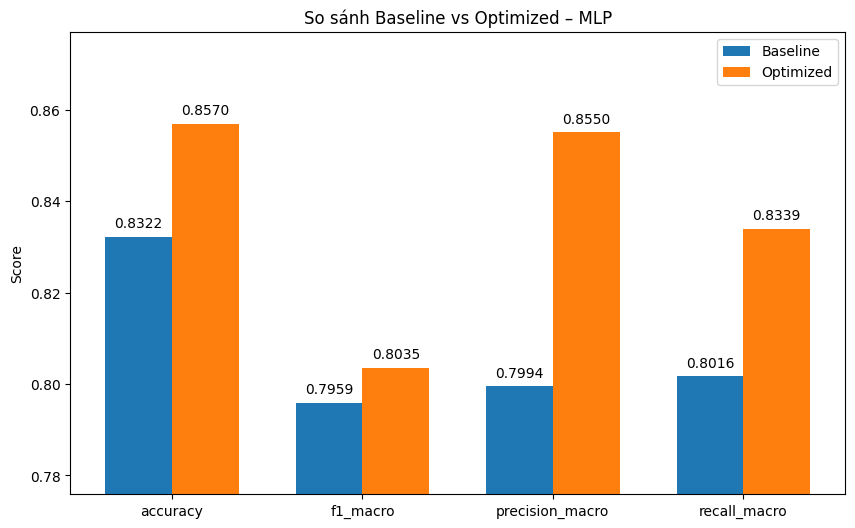

In [42]:
labels = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

baseline_scores = [
    metrics_mlp_base["accuracy"],
    metrics_mlp_base["f1_macro"],
    metrics_mlp_base["precision_macro"],
    metrics_mlp_base["recall_macro"]
]

opt_scores = [
    metrics_mlp_opt["accuracy"],
    metrics_mlp_opt["f1_macro"],
    metrics_mlp_opt["precision_macro"],
    metrics_mlp_opt["recall_macro"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_scores, width, label="Baseline")
plt.bar(x + width/2, opt_scores, width, label="Optimized")

for i, v in enumerate(baseline_scores):
    plt.text(x[i] - width/2, v + 0.002, f"{v:.4f}", ha='center')

for i, v in enumerate(opt_scores):
    plt.text(x[i] + width/2, v + 0.002, f"{v:.4f}", ha='center')

plt.ylim(min(baseline_scores + opt_scores) - 0.02, max(baseline_scores + opt_scores) + 0.02)
plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("So sánh Baseline vs Optimized – MLP")
plt.legend()
plt.show()

## Learning Curve của mô hình MLP

Cell này vẽ learning curve cho mô hình MLP đã tối ưu nhằm quan sát sự thay đổi độ chính xác trên tập huấn luyện và validation theo kích thước dữ liệu, từ đó đánh giá khả năng học và mức độ overfitting của mô hình.


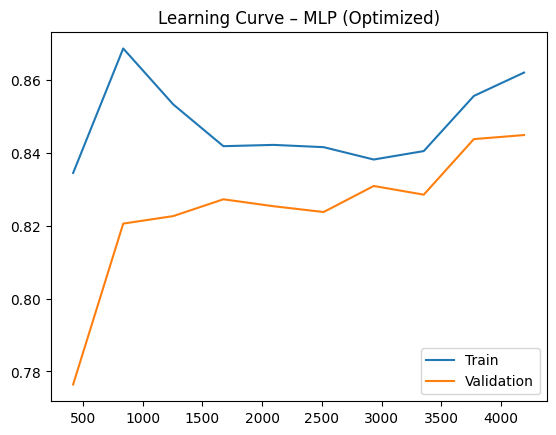

In [43]:
train_sizes, train_scores, test_scores = learning_curve(
    mlp_opt, X_train_scaled, y_train, cv=3,
    scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Validation")
plt.title("Learning Curve – MLP (Optimized)")
plt.legend()
plt.show()

## Đánh giá chi tiết MLP Baseline

Cell này in độ chính xác và báo cáo phân loại cho mô hình MLP baseline, đồng thời trực quan hóa ma trận nhầm lẫn để phân tích các lỗi dự đoán giữa các loại lỗi.


Accuracy (MLP baseline): 0.8321678321678322

Classification report (MLP baseline):
               precision    recall  f1-score   support

          LG       0.92      0.97      0.94       226
          LL       0.98      0.98      0.98       201
         LLG       0.97      0.96      0.97       227
         LLL       0.47      0.30      0.36       219
        LLLG       0.48      0.60      0.53       227
     NoFault       0.98      1.00      0.99       473

    accuracy                           0.83      1573
   macro avg       0.80      0.80      0.80      1573
weighted avg       0.83      0.83      0.82      1573



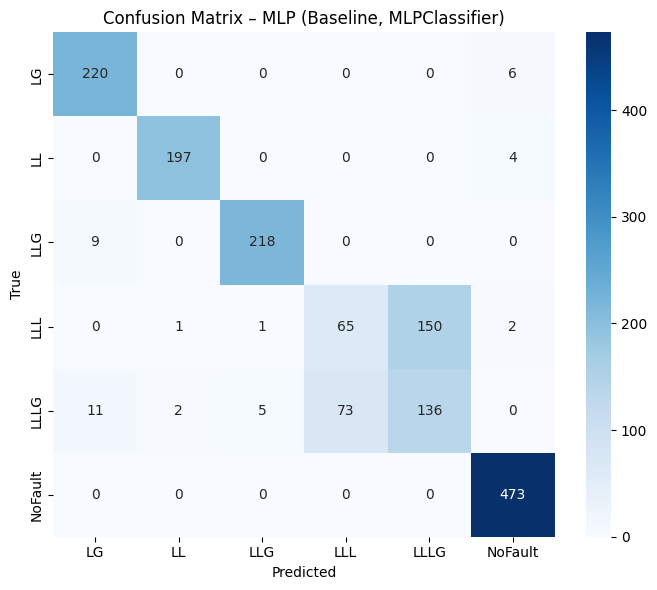

In [44]:
# ===== Confusion Matrix – MLP (Baseline, MLPClassifier) =====


# dự đoán baseline đã có:
# y_pred_mlp_base = mlp_baseline.predict(X_test_scaled)

print("Accuracy (MLP baseline):", accuracy_score(y_test, y_pred_mlp_base))
print("\nClassification report (MLP baseline):\n",
      classification_report(y_test, y_pred_mlp_base))

# Confusion Matrix (count)
cm_base = confusion_matrix(y_test, y_pred_mlp_base, labels=mlp_baseline.classes_)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=mlp_baseline.classes_,
    yticklabels=mlp_baseline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – MLP (Baseline, MLPClassifier)")
plt.tight_layout()
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – MLP Baseline

Cell này chuẩn hóa ma trận nhầm lẫn của mô hình MLP baseline theo từng lớp thực, giúp đánh giá tỷ lệ dự đoán đúng và sai cho mỗi loại lỗi một cách trực quan hơn.


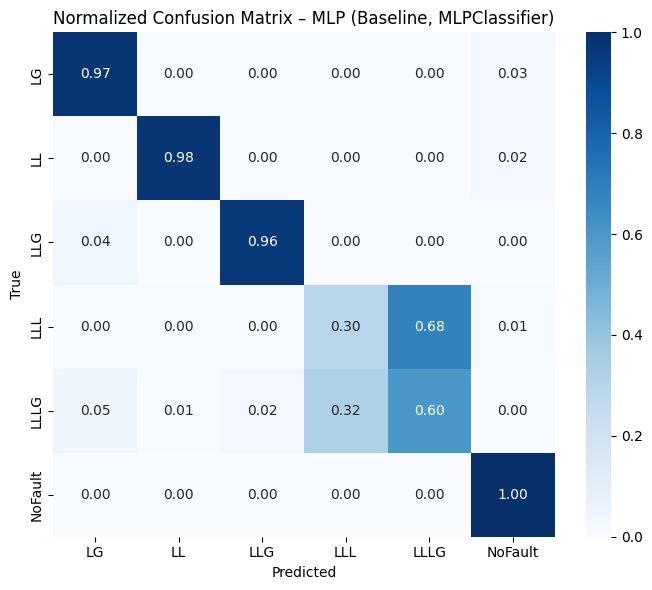

In [45]:
# ===== Normalized Confusion Matrix – MLP (Baseline, MLPClassifier) =====
cm_norm_base = cm_base.astype(np.float32) / np.maximum(cm_base.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm_base,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=mlp_baseline.classes_,
    yticklabels=mlp_baseline.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix – MLP (Baseline, MLPClassifier)")
plt.tight_layout()
plt.show()

## Đánh giá chi tiết MLP tối ưu

Cell này in độ chính xác và báo cáo phân loại của mô hình MLP đã tối ưu, đồng thời hiển thị ma trận nhầm lẫn để phân tích hiệu năng phân loại trên từng loại lỗi.


Accuracy (MLP optimized): 0.8569612205975843

Classification report (MLP optimized):
               precision    recall  f1-score   support

          LG       0.97      1.00      0.99       226
          LL       0.98      0.98      0.98       201
         LLG       1.00      0.97      0.98       227
         LLL       0.51      0.92      0.65       219
        LLLG       0.68      0.13      0.22       227
     NoFault       0.99      1.00      1.00       473

    accuracy                           0.86      1573
   macro avg       0.86      0.83      0.80      1573
weighted avg       0.88      0.86      0.83      1573



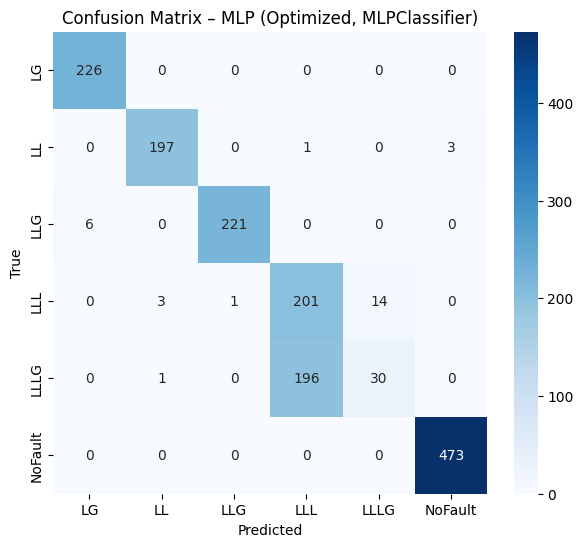

In [46]:
print("Accuracy (MLP optimized):", accuracy_score(y_test, y_pred_mlp_opt))
print("\nClassification report (MLP optimized):\n", classification_report(y_test, y_pred_mlp_opt))

cm = confusion_matrix(y_test, y_pred_mlp_opt, labels=mlp_opt.classes_)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=mlp_opt.classes_,
            yticklabels=mlp_opt.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – MLP (Optimized, MLPClassifier)")
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – MLP tối ưu

Cell này chuẩn hóa ma trận nhầm lẫn của mô hình MLP đã tối ưu theo từng lớp thực, giúp đánh giá rõ hơn tỷ lệ dự đoán đúng và sai cho mỗi loại lỗi.


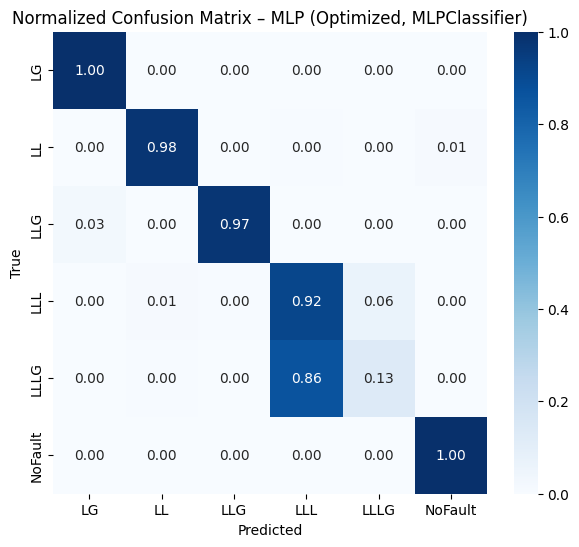

In [47]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm, annot=True, fmt=".2f",
            xticklabels=mlp_opt.classes_,
            yticklabels=mlp_opt.classes_,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix – MLP (Optimized, MLPClassifier)")
plt.show()

## ROC–AUC và Precision–Recall Curve cho MLP

Cell này đánh giá khả năng phân biệt của mô hình MLP đã tối ưu bằng ROC–AUC đa lớp theo chiến lược one-vs-rest, đồng thời trực quan hóa các đường Precision–Recall cho từng loại lỗi.


ROC-AUC macro (MLP): 0.9752408754487005
ROC-AUC weighted (MLP): 0.9789403571046971


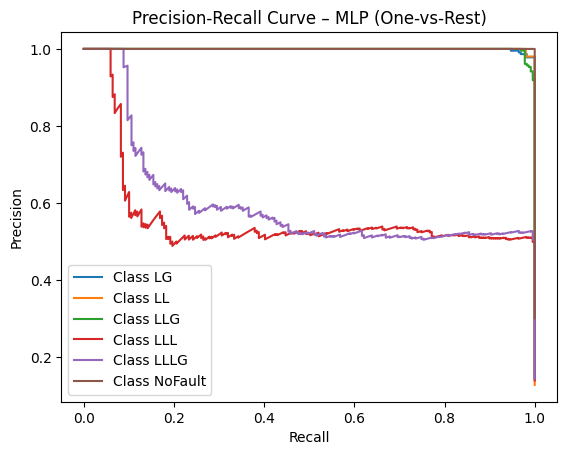

In [48]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

roc_auc_macro = roc_auc_score(y_test_bin, y_proba_mlp_opt, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_test_bin, y_proba_mlp_opt, multi_class="ovr", average="weighted")

print("ROC-AUC macro (MLP):", roc_auc_macro)
print("ROC-AUC weighted (MLP):", roc_auc_weighted)

for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_mlp_opt[:, i])
    plt.plot(recall, precision, label=f"Class {cls}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.title("Precision-Recall Curve – MLP (One-vs-Rest)")
plt.show()

## Minh họa dự đoán của MLP trên tập kiểm tra

Cell này chọn ngẫu nhiên một số mẫu trong tập test và hiển thị kết quả dự đoán của mô hình MLP đã tối ưu, giúp minh họa trực quan mức độ chính xác của mô hình.


In [49]:
# 10 mẫu ngẫu nhiên trong test: True/Pred/Correct
idx = np.random.choice(len(X_test), size=10, replace=False)

X_sample = X_test[idx]
y_true = y_test[idx]

y_pred_sample = mlp_opt.predict(scaler.transform(X_sample))

demo_df = pd.DataFrame(X_sample, columns=features)
demo_df["True"] = y_true
demo_df["Pred"] = y_pred_sample
demo_df["Correct"] = (demo_df["True"] == demo_df["Pred"])

demo_df

,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
0,-822.643826,690.276685,132.364877,-0.004637,0.038811,-0.034175,LLLG,LLL,False
1,2.042805,-24.709177,19.348451,0.591344,-0.304721,-0.286622,NoFault,NoFault,True
2,-166.057522,837.716638,52.612551,0.033085,-0.174587,0.141502,LLG,LLG,True
3,-35.750976,-408.944334,446.947461,-0.494325,-0.034096,0.528421,LL,LL,True
4,505.880543,374.105040,-879.986377,0.042022,-0.025621,-0.016401,LLLG,LLL,False
5,335.277659,540.127008,-875.406931,0.042143,-0.017622,-0.024521,LLLG,LLL,False
6,-415.403834,883.538687,-466.019801,0.023826,0.018423,-0.042249,LLL,LLL,True
7,-511.155975,8.195217,-41.595884,-0.273140,0.584236,-0.311096,LG,LG,True
8,821.224132,-127.428141,-693.794887,0.032236,-0.039958,0.007722,LLLG,LLL,False
9,-16.183059,-14.821689,27.552155,0.559438,-0.433574,-0.125864,NoFault,NoFault,True


## Phân tích các mẫu dự đoán sai của MLP

Cell này xác định các mẫu mà mô hình MLP đã tối ưu dự đoán sai trên tập kiểm tra và hiển thị một số mẫu tiêu biểu, giúp phân tích nguyên nhân nhầm lẫn và hạn chế của mô hình.


In [50]:
# ===== In các mẫu dự đoán SAI (MLP Optimized) =====
y_pred_all = mlp_opt.predict(X_test_scaled)

wrong_idx = np.where(y_pred_all != y_test)[0]
print("Số mẫu dự đoán sai:", len(wrong_idx))

show_n = min(10, len(wrong_idx))
if show_n > 0:
    pick = np.random.choice(wrong_idx, size=show_n, replace=False)

    wrong_df = pd.DataFrame(X_test[pick], columns=features)
    wrong_df["True"] = y_test[pick]
    wrong_df["Pred"] = y_pred_all[pick]
    wrong_df["Correct"] = (wrong_df["True"] == wrong_df["Pred"])

    display(wrong_df)
else:
    print("Không có mẫu nào dự đoán sai.")

Số mẫu dự đoán sai: 225


,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
0,4.448183,-782.419842,778.024690,-0.036089,0.001047,0.035042,LLLG,LLL,False
1,139.906808,-839.151901,699.287145,-0.032631,-0.005416,0.038047,LLLG,LLL,False
2,86.293307,-804.915255,718.619691,-0.035449,-0.002355,0.037804,LLLG,LLL,False
3,-222.632623,851.489216,-628.858429,0.031335,0.009022,-0.040357,LLLG,LLL,False
4,-542.706131,-346.153508,889.011071,-0.041856,0.027033,0.014823,LLLG,LLL,False
5,804.040749,-84.886031,-719.156981,0.033416,-0.039185,0.005769,LLLG,LLL,False
6,-736.751871,-54.214738,790.964345,-0.037124,0.036293,0.000831,LLLG,LLL,False
7,841.326885,-654.771311,-186.557837,0.007217,-0.039717,0.032501,LLLG,LLL,False
8,882.968376,-392.232796,-490.732571,0.022204,-0.042401,0.020196,LLLG,LLL,False
9,826.298004,-141.178844,-685.117980,0.031804,-0.040177,0.008373,LLLG,LLL,False


## Phân tích xác suất dự đoán Top-k của MLP

Cell này hiển thị Top-3 nhãn có xác suất cao nhất cho một số mẫu kiểm tra ngẫu nhiên, giúp đánh giá mức độ tự tin của mô hình MLP và các trường hợp dự đoán có độ cạnh tranh cao giữa các lớp.


In [51]:
# Xem TOP-3 xác suất cho 5 mẫu
idx = np.random.choice(len(X_test), size=5, replace=False)

X_sample = X_test[idx]
y_true = y_test[idx]

proba = mlp_opt.predict_proba(scaler.transform(X_sample))
classes_mlp = mlp_opt.classes_

rows = []
for i in range(len(idx)):
    top3 = np.argsort(proba[i])[::-1][:3]
    rows.append({
        "True": y_true[i],
        "Pred": classes_mlp[top3[0]],
        "P1": float(proba[i][top3[0]]),
        "Top2": classes_mlp[top3[1]],
        "P2": float(proba[i][top3[1]]),
        "Top3": classes_mlp[top3[2]],
        "P3": float(proba[i][top3[2]]),
    })

pd.DataFrame(rows)

,True,Pred,P1,Top2,P2,Top3,P3
0,LLL,LLL,0.641899,LLLG,3.577780e-01,LG,3.232585e-04
1,LL,LL,0.999999,LLL,5.993754e-07,LLLG,1.981150e-07
2,LLL,LLL,0.626895,LLLG,3.685261e-01,LL,4.578698e-03
3,LL,LL,0.999962,NoFault,2.631196e-05,LLLG,7.541969e-06
4,NoFault,NoFault,0.999992,LG,8.243696e-06,LLG,6.448282e-14


## Dự đoán cho mẫu dữ liệu mới bằng MLP

Cell này minh họa cách sử dụng mô hình MLP đã tối ưu để dự đoán loại lỗi cho một mẫu dữ liệu tự nhập, đồng thời hiển thị Top-3 nhãn có xác suất cao nhất nhằm đánh giá độ tin cậy của kết quả dự đoán.


In [52]:
# ===== Dự đoán cho 1 mẫu tự nhập (MLP Optimized) + Top-3 =====
sample = np.array([[
    -151.29, -9.68, 85.80, 0.4007, -0.1329, -0.2678
]], dtype=float)  # thay bằng số bạn muốn

sample_scaled = scaler.transform(sample)

pred = mlp_opt.predict(sample_scaled)[0]
proba = mlp_opt.predict_proba(sample_scaled)[0]
top = np.argsort(proba)[::-1][:3]

print("Predicted FaultType:", pred)
print("Top-3:", [(mlp_opt.classes_[i], float(proba[i])) for i in top])

Predicted FaultType: LG
Top-3: [('LG', 0.9593962831933058), ('LLG', 0.033314084228370316), ('LLLG', 0.004420344992274342)]


# Bước 7 - Huấn luyện mô hình MLP (PyTorch)

## Import thư viện cho MLP (PyTorch)

Cell này khởi tạo các thư viện cần thiết để xây dựng mô hình MLP bằng PyTorch, tạo Dataset/DataLoader, tiền xử lý dữ liệu và đánh giá mô hình bằng các metric/đồ thị tương tự phần sklearn.


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, precision_recall_curve
)
from IPython.display import display

## Nạp dữ liệu và tạo nhãn FaultType

Cell này đọc dữ liệu từ file CSV, tạo nhãn lỗi FaultType dựa trên tổ hợp các cột A–B–C–G, đồng thời loại bỏ các mẫu không khớp mapping để đảm bảo dữ liệu sạch trước khi huấn luyện mô hình PyTorch.


In [54]:
df = pd.read_csv("classData.csv")
print(df.head())
print(df.shape)
print(df.info())

mapping = {
    (0,0,0,0): "NoFault",
    (1,0,0,1): "LG",
    (0,1,1,0): "LL",
    (1,0,1,1): "LLG",
    (0,1,1,1): "LLL",
    (1,1,1,1): "LLLG"
}

df["FaultType"] = df[["G","C","B","A"]].apply(lambda r: mapping.get(tuple(r), None), axis=1)

# nếu có dòng nào không khớp mapping -> bỏ (để tránh lỗi/nhãn rác)
before = len(df)
df = df.dropna(subset=["FaultType"]).reset_index(drop=True)
after = len(df)
print("Dropped rows (unmapped):", before - after)

print(df["FaultType"].value_counts())

   G  C  B  A          Ia          Ib          Ic        Va        Vb  \
0  1  0  0  1 -151.291812   -9.677452   85.800162  0.400750 -0.132935   
1  1  0  0  1 -336.186183  -76.283262   18.328897  0.312732 -0.123633   
2  1  0  0  1 -502.891583 -174.648023  -80.924663  0.265728 -0.114301   
3  1  0  0  1 -593.941905 -217.703359 -124.891924  0.235511 -0.104940   
4  1  0  0  1 -643.663617 -224.159427 -132.282815  0.209537 -0.095554   

         Vc  
0 -0.267815  
1 -0.189099  
2 -0.151428  
3 -0.130570  
4 -0.113983  
(7861, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7861 entries, 0 to 7860
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   G       7861 non-null   int64  
 1   C       7861 non-null   int64  
 2   B       7861 non-null   int64  
 3   A       7861 non-null   int64  
 4   Ia      7861 non-null   float64
 5   Ib      7861 non-null   float64
 6   Ic      7861 non-null   float64
 7   Va      7861 non-null

## Chia tập Train/Val/Test, chuẩn hóa và mã hóa nhãn

Cell này chia dữ liệu thành 3 tập train/validation/test theo tỷ lệ 70/15/15 (giữ phân bố lớp bằng stratify), chuẩn hóa đặc trưng bằng StandardScaler dựa trên train, và mã hóa nhãn FaultType từ dạng chuỗi sang số nguyên để dùng cho huấn luyện mô hình PyTorch.


In [55]:
X = df[features].values.astype(np.float32)
y_str = df["FaultType"].values.astype(str)

X_temp, X_test, y_temp, y_test_str = train_test_split(
    X, y_str,
    test_size=0.15,
    random_state=42,
    stratify=y_str
)

X_train, X_val, y_train_str, y_val_str = train_test_split(
    X_temp, y_temp,
    test_size=0.17647058823529413,  # = 0.15 / 0.85 để val = 15% tổng
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

# encode label string -> int (0..C-1)
classes = sorted(np.unique(y_train_str).tolist())
cls2id = {c:i for i,c in enumerate(classes)}
id2cls = {i:c for c,i in cls2id.items()}

y_train = np.array([cls2id[c] for c in y_train_str], dtype=np.int64)
y_val   = np.array([cls2id[c] for c in y_val_str], dtype=np.int64)
y_test  = np.array([cls2id[c] for c in y_test_str], dtype=np.int64)

print("Classes:", classes)
print("Train:", X_train_scaled.shape, y_train.shape)
print("Val  :", X_val_scaled.shape, y_val.shape)
print("Test :", X_test_scaled.shape, y_test.shape)

Classes: ['LG', 'LL', 'LLG', 'LLL', 'LLLG', 'NoFault']
Train: (5502, 6) (5502,)
Val  : (1179, 6) (1179,)
Test : (1180, 6) (1180,)


## Xây dựng Dataset, DataLoader và thiết lập thiết bị

Cell này định nghĩa Dataset tùy chỉnh cho bài toán phân loại lỗi, tạo các DataLoader cho train/validation/test và thiết lập thiết bị huấn luyện (GPU nếu có, ngược lại dùng CPU).


In [56]:
class FaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 64
train_loader = DataLoader(FaultDataset(X_train_scaled, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(FaultDataset(X_val_scaled,   y_val),   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(FaultDataset(X_test_scaled,  y_test),  batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Thiết lập seed để đảm bảo tái lập kết quả

Cell này đặt seed cho NumPy và PyTorch nhằm đảm bảo quá trình huấn luyện và đánh giá mô hình có thể tái lập được giữa các lần chạy.


In [57]:
# ---- Reproducibility ----
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

## Định nghĩa kiến trúc MLP bằng PyTorch

Cell này xây dựng kiến trúc mạng MLP với số tầng ẩn linh hoạt, hàm kích hoạt ReLU và tùy chọn dropout, dùng cho bài toán phân loại đa lớp.


In [58]:
# ---- Model ----
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Các hàm huấn luyện, đánh giá và tính metric (PyTorch)

Cell này định nghĩa các hàm phục vụ pipeline huấn luyện MLP:
- train/evaluate theo từng epoch (tính loss và accuracy),
- dự đoán xác suất (softmax) để phục vụ ROC/PR,
- tính các metric tổng hợp,
- fit_model: huấn luyện đầy đủ với early stopping theo validation và trả về mô hình tốt nhất cùng kết quả đánh giá trên test.


In [59]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    losses = []
    preds_all, y_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)

        preds_all.append(preds.detach().cpu().numpy())
        y_all.append(yb.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    y_all = np.concatenate(y_all)
    acc = accuracy_score(y_all, preds_all)
    return float(np.mean(losses)), float(acc)

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    losses = []
    preds_all, y_all = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1)

        preds_all.append(preds.detach().cpu().numpy())
        y_all.append(yb.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all)
    y_all = np.concatenate(y_all)
    acc = accuracy_score(y_all, preds_all)
    return float(np.mean(losses)), float(acc), preds_all, y_all

@torch.no_grad()
def predict_probs(model, loader, device):
    model.eval()
    all_probs = []
    all_y = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_y.append(yb.numpy())
    return np.concatenate(all_y), np.concatenate(all_probs)

def calc_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def fit_model(cfg, train_loader, val_loader, test_loader, device, in_dim, out_dim):
    set_seed(42)

    model = MLP(in_dim, cfg["hidden_dims"], out_dim, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg.get("weight_decay", 0.0)
    )

    epochs = cfg.get("epochs", 80)
    patience = cfg.get("patience", 10)

    best_val_acc = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion, device)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if cfg.get("verbose", True):
            print(f"Epoch {ep:03d} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
                f"| val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    te_loss, te_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
    metrics = calc_metrics(y_true, y_pred)

    return model, best_val_acc, te_acc, metrics, (y_true, y_pred)

## Huấn luyện MLP PyTorch (Baseline)

Cell này thiết lập cấu hình baseline cho mô hình MLP PyTorch với kiến trúc đơn giản, sau đó huấn luyện và đánh giá mô hình để làm mốc so sánh cho các cấu hình cải tiến.


In [60]:
in_dim = X_train_scaled.shape[1]
out_dim = len(classes)

baseline_cfg = {
    "hidden_dims": [32],     # baseline nhỏ
    "dropout": 0.0,
    "lr": 1e-3,
    "weight_decay": 0.0,
    "epochs": 80,
    "patience": 10,
    "verbose": True
}

mlp_base, base_val_acc, base_test_acc, metrics_base, (y_true_base, y_pred_base) = fit_model(
    baseline_cfg, train_loader, val_loader, test_loader, device, in_dim, out_dim
)

print("MLP PyTorch Baseline - val_acc:", base_val_acc)
print("MLP PyTorch Baseline metrics:", metrics_base)

Epoch 001 | train_loss=1.6712 train_acc=0.3010 | val_loss=1.5620 val_acc=0.3707
Epoch 002 | train_loss=1.4440 train_acc=0.4235 | val_loss=1.3322 val_acc=0.4733
Epoch 003 | train_loss=1.2088 train_acc=0.5440 | val_loss=1.1112 val_acc=0.5861
Epoch 004 | train_loss=1.0100 train_acc=0.6474 | val_loss=0.9367 val_acc=0.6633
Epoch 005 | train_loss=0.8555 train_acc=0.6970 | val_loss=0.8010 val_acc=0.7150
Epoch 006 | train_loss=0.7392 train_acc=0.7379 | val_loss=0.7001 val_acc=0.7464
Epoch 007 | train_loss=0.6540 train_acc=0.7635 | val_loss=0.6298 val_acc=0.7795
Epoch 008 | train_loss=0.5932 train_acc=0.7819 | val_loss=0.5773 val_acc=0.7854
Epoch 009 | train_loss=0.5485 train_acc=0.7944 | val_loss=0.5392 val_acc=0.7990
Epoch 010 | train_loss=0.5143 train_acc=0.7977 | val_loss=0.5090 val_acc=0.8032
Epoch 011 | train_loss=0.4867 train_acc=0.8064 | val_loss=0.4847 val_acc=0.8015
Epoch 012 | train_loss=0.4645 train_acc=0.8106 | val_loss=0.4645 val_acc=0.8176
Epoch 013 | train_loss=0.4457 train_acc=

## Tìm kiếm cấu hình tối ưu cho MLP PyTorch

Cell này thử nghiệm nhiều cấu hình MLP khác nhau (số tầng ẩn, dropout, learning rate, weight decay) và chọn mô hình có độ chính xác validation cao nhất để làm mô hình tối ưu.


In [61]:
search_space = [
    {"hidden_dims":[64],      "dropout":0.1, "lr":1e-3, "weight_decay":1e-5},
    {"hidden_dims":[64, 32],  "dropout":0.2, "lr":1e-3, "weight_decay":1e-5},
    {"hidden_dims":[128, 64], "dropout":0.2, "lr":1e-3, "weight_decay":1e-5},
    {"hidden_dims":[128, 64], "dropout":0.3, "lr":5e-4, "weight_decay":1e-4},
]

best_cfg = None
best_val = -1.0
best_pack = None

for cfg0 in search_space:
    cfg = {
        **cfg0,
        "epochs": 80,
        "patience": 10,
        "verbose": True
    }
    model_tmp, v_acc, t_acc, metrics_tmp, pack_tmp = fit_model(
        cfg, train_loader, val_loader, test_loader, device, in_dim, out_dim
    )
    if v_acc > best_val:
        best_val = v_acc
        best_cfg = cfg0
        best_pack = (model_tmp, v_acc, t_acc, metrics_tmp, pack_tmp)

mlp_opt, opt_val_acc, opt_test_acc, metrics_opt, (y_true_opt, y_pred_opt) = best_pack

print("Best cfg (Optimized):", best_cfg)
print("MLP PyTorch Optimized - val_acc:", opt_val_acc)
print("MLP PyTorch Optimized metrics:", metrics_opt)

Epoch 001 | train_loss=1.6173 train_acc=0.3006 | val_loss=1.4495 val_acc=0.4139
Epoch 002 | train_loss=1.2740 train_acc=0.5207 | val_loss=1.0992 val_acc=0.6098
Epoch 003 | train_loss=0.9573 train_acc=0.6732 | val_loss=0.8318 val_acc=0.7023
Epoch 004 | train_loss=0.7535 train_acc=0.7301 | val_loss=0.6789 val_acc=0.7506
Epoch 005 | train_loss=0.6380 train_acc=0.7679 | val_loss=0.5915 val_acc=0.7837
Epoch 006 | train_loss=0.5655 train_acc=0.7861 | val_loss=0.5326 val_acc=0.7956
Epoch 007 | train_loss=0.5149 train_acc=0.8006 | val_loss=0.4928 val_acc=0.8015
Epoch 008 | train_loss=0.4813 train_acc=0.8046 | val_loss=0.4651 val_acc=0.7998
Epoch 009 | train_loss=0.4535 train_acc=0.8104 | val_loss=0.4413 val_acc=0.8075
Epoch 010 | train_loss=0.4344 train_acc=0.8121 | val_loss=0.4236 val_acc=0.8227
Epoch 011 | train_loss=0.4184 train_acc=0.8153 | val_loss=0.4104 val_acc=0.8227
Epoch 012 | train_loss=0.4048 train_acc=0.8148 | val_loss=0.3982 val_acc=0.8227
Epoch 013 | train_loss=0.3894 train_acc=

# Bước 8 - Đánh giá mô hình MLP (PyTorch)

## So sánh hiệu năng MLP PyTorch Baseline và Optimized

Cell này tổng hợp các chỉ số đánh giá của mô hình MLP PyTorch baseline và mô hình đã tối ưu vào một bảng so sánh, giúp quan sát rõ mức độ cải thiện hiệu năng sau quá trình tinh chỉnh cấu hình.


In [62]:
compare_df = pd.DataFrame({
    "Metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    "Baseline": [
        metrics_base["accuracy"],
        metrics_base["precision_macro"],
        metrics_base["recall_macro"],
        metrics_base["f1_macro"]
    ],
    "Optimized": [
        metrics_opt["accuracy"],
        metrics_opt["precision_macro"],
        metrics_opt["recall_macro"],
        metrics_opt["f1_macro"]
    ]
})

compare_df

,Metric,Baseline,Optimized
0,accuracy,0.838136,0.847458
1,precision_macro,0.794821,0.818006
2,recall_macro,0.811701,0.819113
3,f1_macro,0.782281,0.800782


## So sánh trực quan hiệu năng MLP PyTorch

Cell này sử dụng biểu đồ cột để so sánh trực quan các chỉ số đánh giá giữa mô hình MLP PyTorch baseline và mô hình đã tối ưu, giúp dễ dàng nhận thấy mức độ cải thiện hiệu năng.


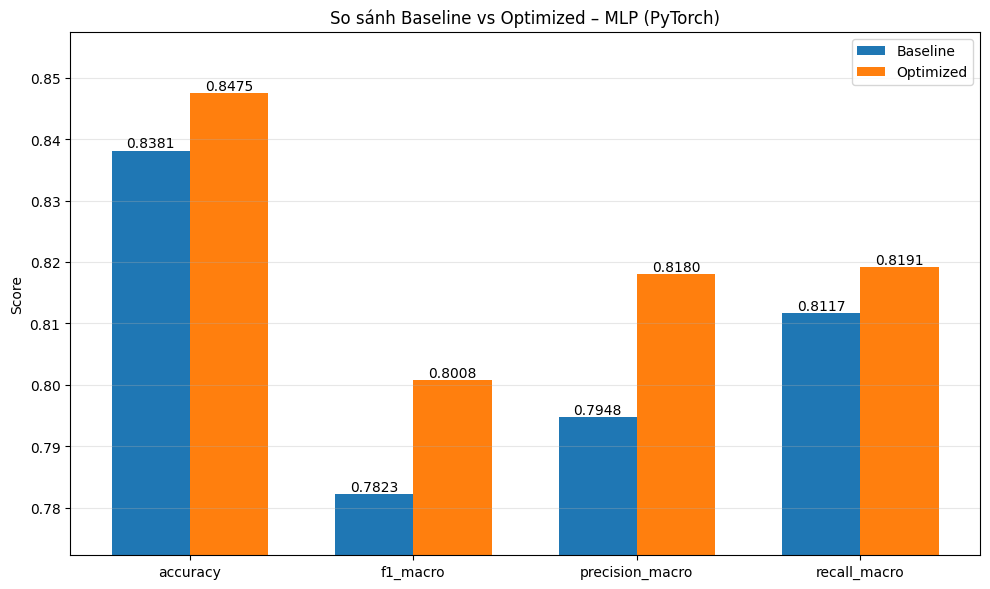

In [63]:
labels = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

baseline_scores = [
    metrics_base["accuracy"],
    metrics_base["f1_macro"],
    metrics_base["precision_macro"],
    metrics_base["recall_macro"]
]

opt_scores = [
    metrics_opt["accuracy"],
    metrics_opt["f1_macro"],
    metrics_opt["precision_macro"],
    metrics_opt["recall_macro"]
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, baseline_scores, width, label="Baseline")
plt.bar(x + width/2, opt_scores, width, label="Optimized")

# hiển thị giá trị trên cột
for i, v in enumerate(baseline_scores):
    plt.text(x[i] - width/2, v + 0.0005, f"{v:.4f}", ha='center', fontsize=10)

for i, v in enumerate(opt_scores):
    plt.text(x[i] + width/2, v + 0.0005, f"{v:.4f}", ha='center', fontsize=10)

# ZOOM TRỤC Y
y_min = min(baseline_scores + opt_scores) - 0.01
y_max = max(baseline_scores + opt_scores) + 0.01
plt.ylim(y_min, y_max)

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("So sánh Baseline vs Optimized – MLP (PyTorch)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Đánh giá chi tiết MLP PyTorch Baseline

Cell này in độ chính xác cuối cùng trên tập test và báo cáo phân loại cho mô hình MLP PyTorch baseline, đồng thời trực quan hóa ma trận nhầm lẫn để phân tích các lỗi dự đoán giữa các loại lỗi.


Final test_acc (Baseline): 0.838135593220339

Classification report (Baseline):

              precision    recall  f1-score   support

          LG     0.9535    0.9704    0.9619       169
          LL     0.9804    0.9934    0.9868       151
         LLG     0.9432    0.9765    0.9595       170
         LLL     0.4982    0.8182    0.6193       165
        LLLG     0.4130    0.1118    0.1759       170
     NoFault     0.9807    1.0000    0.9902       355

    accuracy                         0.8381      1180
   macro avg     0.7948    0.8117    0.7823      1180
weighted avg     0.8221    0.8381    0.8121      1180



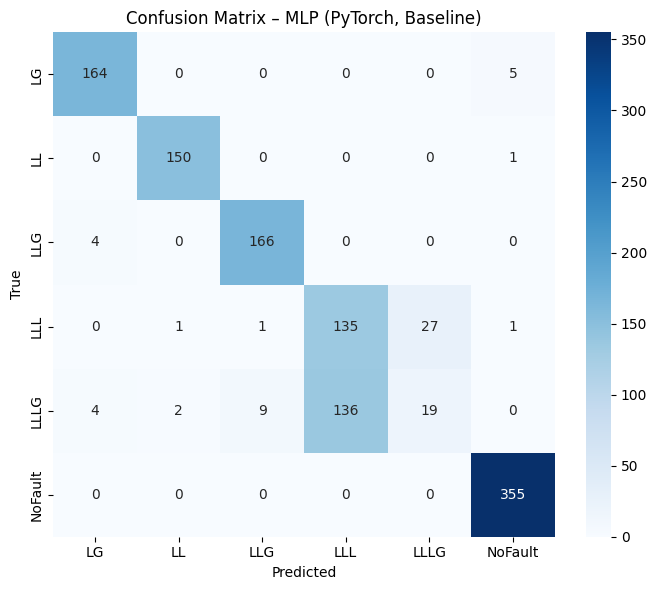

In [64]:
# ===== Evaluate + Report/CM cho Baseline MLP (PyTorch) =====
# dùng output của baseline: (y_true_base, y_pred_base) và base_test_acc

print("Final test_acc (Baseline):", base_test_acc)

labels = list(range(len(classes)))
target_names = [id2cls[i] for i in labels]

print("\nClassification report (Baseline):\n")
print(classification_report(
    y_true_base, y_pred_base,
    labels=labels,
    target_names=target_names,
    digits=4
))

cm_base = confusion_matrix(y_true_base, y_pred_base)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – MLP (PyTorch, Baseline)")
plt.tight_layout()
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – MLP PyTorch Baseline

Cell này chuẩn hóa ma trận nhầm lẫn của mô hình MLP PyTorch baseline theo từng lớp thực, giúp đánh giá rõ tỷ lệ dự đoán đúng và sai cho mỗi loại lỗi.


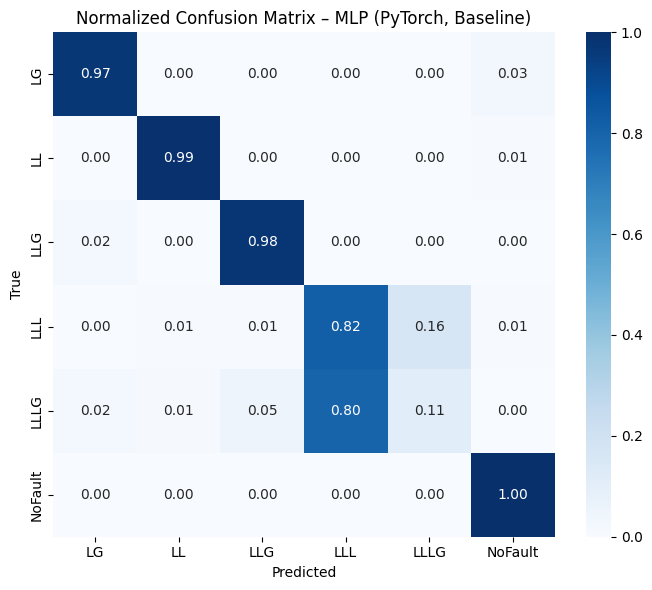

In [65]:
# ===== Normalized Confusion Matrix cho Baseline MLP (PyTorch) =====

cm_base = confusion_matrix(y_true_base, y_pred_base)

# Normalize theo hàng (True label) – tránh chia 0
row_sum = cm_base.sum(axis=1, keepdims=True)
cm_norm_base = cm_base.astype(np.float32) / np.maximum(row_sum, 1)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm_base,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix – MLP (PyTorch, Baseline)")
plt.tight_layout()
plt.show()

## Đánh giá chi tiết MLP PyTorch Optimized

Cell này in độ chính xác cuối cùng trên tập test và báo cáo phân loại cho mô hình MLP PyTorch đã tối ưu, đồng thời hiển thị ma trận nhầm lẫn để phân tích hiệu năng trên từng loại lỗi.


Final test_acc (Optimized): 0.847457627118644

Classification report (Optimized):

              precision    recall  f1-score   support

          LG     0.9767    0.9941    0.9853       169
          LL     0.9867    0.9801    0.9834       151
         LLG     0.9651    0.9765    0.9708       170
         LLL     0.4915    0.1758    0.2589       165
        LLLG     0.5019    0.7882    0.6133       170
     NoFault     0.9861    1.0000    0.9930       355

    accuracy                         0.8475      1180
   macro avg     0.8180    0.8191    0.8008      1180
weighted avg     0.8429    0.8475    0.8301      1180



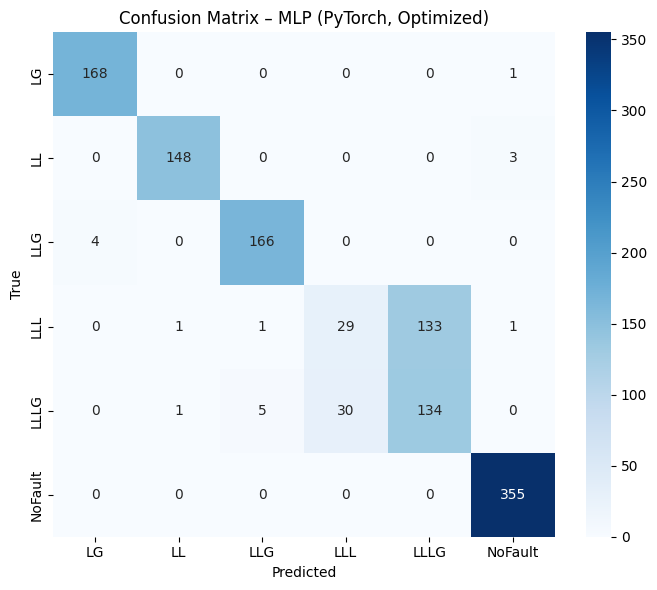

In [66]:
# ===== Evaluate + Report/CM cho Optimized MLP (PyTorch) =====
# dùng output của optimized: (y_true_opt, y_pred_opt) và opt_test_acc

print("Final test_acc (Optimized):", opt_test_acc)

labels = list(range(len(classes)))
target_names = [id2cls[i] for i in labels]

print("\nClassification report (Optimized):\n")
print(classification_report(
    y_true_opt, y_pred_opt,
    labels=labels,
    target_names=target_names,
    digits=4
))

cm_opt = confusion_matrix(y_true_opt, y_pred_opt)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – MLP (PyTorch, Optimized)")
plt.tight_layout()
plt.show()

## Ma trận nhầm lẫn chuẩn hóa – MLP PyTorch Optimized

Cell này chuẩn hóa ma trận nhầm lẫn của mô hình MLP PyTorch đã tối ưu theo từng lớp thực, giúp đánh giá trực quan tỷ lệ dự đoán đúng và sai của từng loại lỗi sau quá trình tối ưu mô hình.


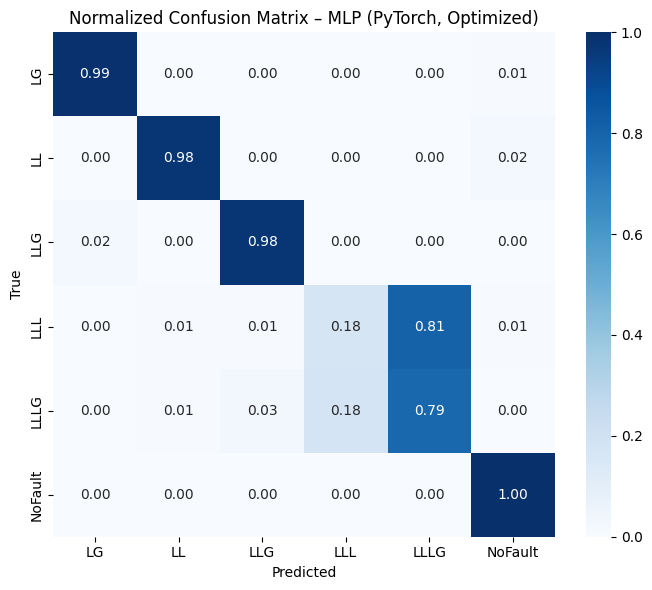

In [67]:
# ===== Normalized Confusion Matrix cho Optimized MLP (PyTorch) =====

cm_opt = confusion_matrix(y_true_opt, y_pred_opt)

# Normalize theo hàng (True label) – tránh chia 0
row_sum = cm_opt.sum(axis=1, keepdims=True)
cm_norm_opt = cm_opt.astype(np.float32) / np.maximum(row_sum, 1)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_norm_opt,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix – MLP (PyTorch, Optimized)")
plt.tight_layout()
plt.show()

## ROC–AUC và Precision–Recall Curve cho MLP PyTorch (Optimized)

Cell này lấy xác suất dự đoán (softmax) của mô hình MLP PyTorch đã tối ưu trên tập test, chuyển nhãn sang dạng one-vs-rest và tính ROC–AUC (macro/weighted). Sau đó vẽ ROC curve theo từng lớp (kèm micro/macro average) và vẽ Precision–Recall curve để đánh giá khả năng phân biệt của mô hình trên bài toán đa lớp.


ROC-AUC macro (MLP PyTorch, Optimized): 0.9725293173879046
ROC-AUC weighted (MLP PyTorch, Optimized): 0.9765914060076365


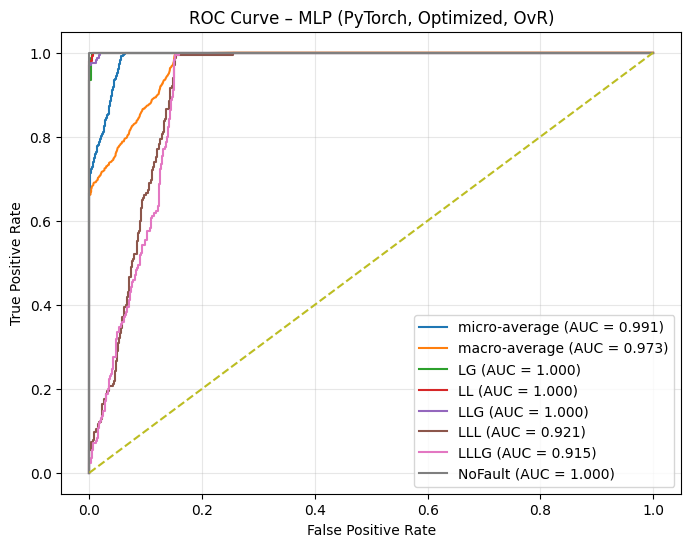

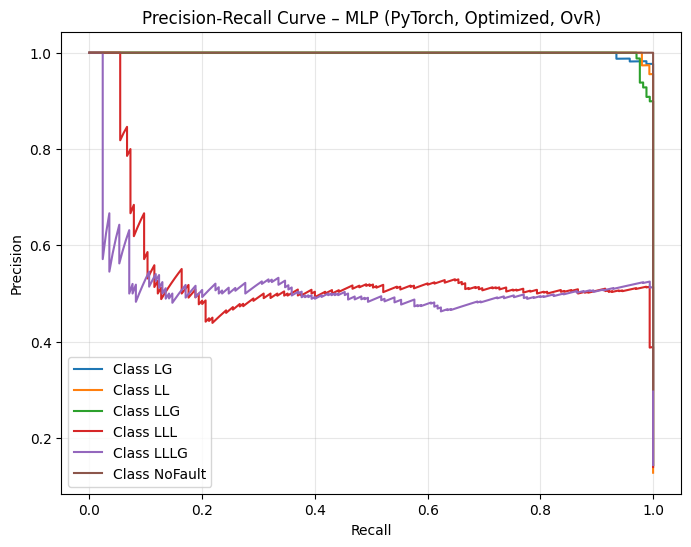

In [68]:
@torch.no_grad()
def predict_proba_opt(model, loader, device):
    model.eval()
    all_proba = []
    all_y = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        proba = F.softmax(logits, dim=1)
        all_proba.append(proba.cpu().numpy())
        all_y.append(yb.cpu().numpy())
    y_true = np.concatenate(all_y)
    y_proba = np.concatenate(all_proba)
    return y_true, y_proba

# ===== ROC/PR cho Optimized MLP (PyTorch) =====
y_true_opt, y_proba_opt = predict_proba_opt(mlp_opt, test_loader, device)

C = y_proba_opt.shape[1]
classes_int = np.arange(C)
y_true_bin = label_binarize(y_true_opt, classes=classes_int)

roc_auc_macro = roc_auc_score(y_true_bin, y_proba_opt, multi_class="ovr", average="macro")
roc_auc_weighted = roc_auc_score(y_true_bin, y_proba_opt, multi_class="ovr", average="weighted")
print("ROC-AUC macro (MLP PyTorch, Optimized):", roc_auc_macro)
print("ROC-AUC weighted (MLP PyTorch, Optimized):", roc_auc_weighted)

# ROC per-class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(C):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba_opt[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba_opt.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(C)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(C):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= C
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8,6))
plt.plot(fpr["micro"], tpr["micro"], label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], label=f"macro-average (AUC = {roc_auc['macro']:.3f})")
for i in range(C):
    plt.plot(fpr[i], tpr[i], label=f"{id2cls[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MLP (PyTorch, Optimized, OvR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Precision–Recall curve
plt.figure(figsize=(8,6))
for i in range(C):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_proba_opt[:, i])
    plt.plot(recall, precision, label=f"Class {id2cls[i]}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – MLP (PyTorch, Optimized, OvR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Minh họa dự đoán của MLP PyTorch trên tập kiểm tra

Cell này chọn ngẫu nhiên một số mẫu trong tập test, thực hiện dự đoán bằng mô hình MLP PyTorch đã tối ưu và hiển thị so sánh giữa nhãn thực và nhãn dự đoán, giúp minh họa trực quan độ chính xác của mô hình.


In [69]:
# ===== 10 mẫu ngẫu nhiên trong test: True/Pred/Correct (Optimized MLP PyTorch) =====
mlp_opt.eval()

idx = np.random.choice(len(X_test), size=10, replace=False)

X_sample = X_test[idx]     # CHƯA scale (để show bảng đẹp)
y_true_sample = y_test[idx]

X_sample_scaled = scaler.transform(X_sample).astype(np.float32)

with torch.no_grad():
    xb = torch.tensor(X_sample_scaled, dtype=torch.float32).to(device)
    logits = mlp_opt(xb)
    y_pred_sample = torch.argmax(logits, dim=1).cpu().numpy()

demo_df = pd.DataFrame(X_sample, columns=features)
demo_df["True"] = [id2cls[int(t)] for t in y_true_sample]
demo_df["Pred"] = [id2cls[int(p)] for p in y_pred_sample]
demo_df["Correct"] = (demo_df["True"] == demo_df["Pred"])

demo_df

,Ia,Ib,Ic,Va,Vb,Vc,True,Pred,Correct
0,-687.584229,-136.972122,824.554077,-0.038883,0.034071,0.004813,LLLG,LLLG,True
1,703.862915,-822.730469,118.880051,-0.007023,-0.032710,0.039733,LLLG,LLLG,True
2,-247.112045,-627.317810,876.596558,-0.041003,0.013147,0.027856,LLL,LLLG,False
3,10.365164,76.118721,-89.624939,-0.540763,0.541436,-0.000673,NoFault,NoFault,True
4,5.219489,-741.652954,738.955139,-0.312253,-0.011754,0.324007,LL,LL,True
5,-102.259087,-53.383373,49.352894,0.382478,-0.540228,0.157750,LG,LG,True
6,-61.027771,29.170473,28.642023,0.211703,-0.579798,0.368095,NoFault,NoFault,True
7,-380.840973,20.162220,-45.724812,-0.315171,0.603154,-0.287983,LG,LG,True
8,-65.323303,83.578957,-21.251942,-0.382126,-0.212551,0.594677,NoFault,NoFault,True
9,-584.149719,-263.459839,-50.692757,-0.041019,0.371620,-0.330600,LLG,LLG,True


## Phân tích các mẫu dự đoán sai của MLP PyTorch

Cell này xác định các mẫu mà mô hình MLP PyTorch đã tối ưu dự đoán sai trên toàn bộ tập test và hiển thị một số mẫu tiêu biểu, giúp phân tích nguyên nhân nhầm lẫn và hạn chế của mô hình.


In [70]:
# ===== Các mẫu dự đoán SAI (Optimized MLP PyTorch) =====
mlp_opt.eval()

# dự đoán cho TOÀN BỘ test (dùng X_test_scaled đúng như pipeline)
with torch.no_grad():
    xb_all = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
    logits_all = mlp_opt(xb_all)
    y_pred_all = torch.argmax(logits_all, dim=1).cpu().numpy()

wrong_idx = np.where(y_pred_all != y_test)[0]
print("Số mẫu dự đoán sai:", len(wrong_idx))

# lấy tối đa 10 mẫu sai để xem
show_n = min(10, len(wrong_idx))
if show_n == 0:
    print("Không có mẫu dự đoán sai.")
else:
    pick = np.random.choice(wrong_idx, size=show_n, replace=False)

    wrong_df = pd.DataFrame(X_test[pick], columns=features)  # X_test CHƯA scale để nhìn dễ
    wrong_df["True"] = [id2cls[int(t)] for t in y_test[pick]]
    wrong_df["Pred"] = [id2cls[int(p)] for p in y_pred_all[pick]]
    display(wrong_df)

Số mẫu dự đoán sai: 180


,Ia,Ib,Ic,Va,Vb,Vc,True,Pred
0,155.688843,-830.327881,676.639465,-0.033510,-0.005681,0.039191,LLL,LLLG
1,873.907166,-553.099915,-318.744202,0.013663,-0.041526,0.027863,LLL,LLLG
2,885.021301,-476.459656,-406.419159,0.018141,-0.042298,0.024157,LLL,LLLG
3,641.486694,80.271591,13.784354,0.121380,-0.434841,0.313461,LLLG,LLG
4,551.984802,29.164293,31.850151,0.215944,-0.525135,0.309191,LLG,LG
5,341.740814,-875.894104,536.229248,-0.027048,-0.014698,0.041746,LLL,LLLG
6,-866.631592,288.141357,580.509766,-0.026472,0.041903,-0.015431,LLL,LLLG
7,-650.682190,-190.749832,843.523621,-0.039857,0.032404,0.007453,LLL,LLLG
8,-242.780304,-613.283447,858.148315,-0.041502,0.013365,0.028137,LLL,LLLG
9,748.423767,-781.053650,34.698109,-0.003382,-0.034854,0.038236,LLL,LLLG


## Phân tích xác suất dự đoán Top-k của MLP PyTorch

Cell này hiển thị Top-3 nhãn có xác suất cao nhất cho một số mẫu kiểm tra ngẫu nhiên, giúp đánh giá mức độ tự tin của mô hình MLP PyTorch và các trường hợp nhãn dự đoán cạnh tranh gần nhau.


In [71]:
# ===== TOP-3 xác suất cho 5 mẫu (Optimized MLP PyTorch) =====
mlp_opt.eval()

idx = np.random.choice(len(X_test), size=5, replace=False)

X_sample = X_test[idx]
y_true_sample = y_test[idx]

X_sample_scaled = scaler.transform(X_sample).astype(np.float32)

with torch.no_grad():
    xb = torch.tensor(X_sample_scaled, dtype=torch.float32).to(device)
    logits = mlp_opt(xb)
    proba = F.softmax(logits, dim=1).cpu().numpy()   # (N, C)

classes_pt = [id2cls[i] for i in range(len(classes))]

rows = []
for i in range(len(idx)):
    top3 = np.argsort(proba[i])[::-1][:3]
    rows.append({
        "True": id2cls[int(y_true_sample[i])],
        "Pred": classes_pt[top3[0]],
        "P1": float(proba[i][top3[0]]),
        "Top2": classes_pt[top3[1]],
        "P2": float(proba[i][top3[1]]),
        "Top3": classes_pt[top3[2]],
        "P3": float(proba[i][top3[2]]),
    })

pd.DataFrame(rows)

,True,Pred,P1,Top2,P2,Top3,P3
0,LG,LG,0.999996,NoFault,0.000004,LLG,8.394374e-11
1,LLLG,LLL,0.533027,LLLG,0.466897,LL,7.620455e-05
2,NoFault,NoFault,0.994007,LG,0.005993,LL,3.365026e-14
3,LLL,LLL,0.504608,LLLG,0.495392,LG,8.128428e-08
4,LLL,LLLG,0.490087,LLL,0.398602,LL,1.113104e-01


## Dự đoán cho mẫu dữ liệu mới bằng MLP PyTorch

Cell này minh họa cách sử dụng mô hình MLP PyTorch đã tối ưu để dự đoán loại lỗi cho một mẫu dữ liệu tự nhập, đồng thời hiển thị Top-3 nhãn có xác suất cao nhất nhằm đánh giá độ tin cậy của kết quả dự đoán.


In [72]:
# ===== Dự đoán cho 1 mẫu tự nhập (Optimized MLP PyTorch) =====
mlp_opt.eval()

sample = np.array([[
    -151.29, -9.68, 85.80, 0.4007, -0.1329, -0.2678
]], dtype=np.float32)  # thay bằng số bạn muốn (Ia, Ib, Ic, Va, Vb, Vc)

sample_scaled = scaler.transform(sample).astype(np.float32)

with torch.no_grad():
    xb = torch.tensor(sample_scaled, dtype=torch.float32).to(device)
    logits = mlp_opt(xb)                       # (1, C)
    proba = F.softmax(logits, dim=1).cpu().numpy()[0]   # (C,)

top = np.argsort(proba)[::-1][:3]
pred_id = int(top[0])

print("Predicted FaultType:", id2cls[pred_id])
print("Top-3:", [(id2cls[int(i)], float(proba[int(i)])) for i in top])

Predicted FaultType: NoFault
Top-3: [('NoFault', 0.31267470121383667), ('LL', 0.3064596652984619), ('LG', 0.22663336992263794)]


## Learning Curve cho MLP PyTorch (Baseline vs Optimized)

Cell này xây dựng learning curve cho MLP PyTorch bằng cách huấn luyện mô hình trên nhiều kích thước tập train khác nhau (fit scaler riêng cho từng subset để tránh leakage), lặp nhiều lần để giảm nhiễu và ghi nhận accuracy tốt nhất trên train/validation. Kết quả được vẽ để so sánh trực quan khả năng học và mức độ overfitting giữa cấu hình baseline và cấu hình optimized.


train_sizes: [200, 400, 600, 800, 1000, 1400, 1800, 2200, 2600, 3000, 3400, 3800, 4200]


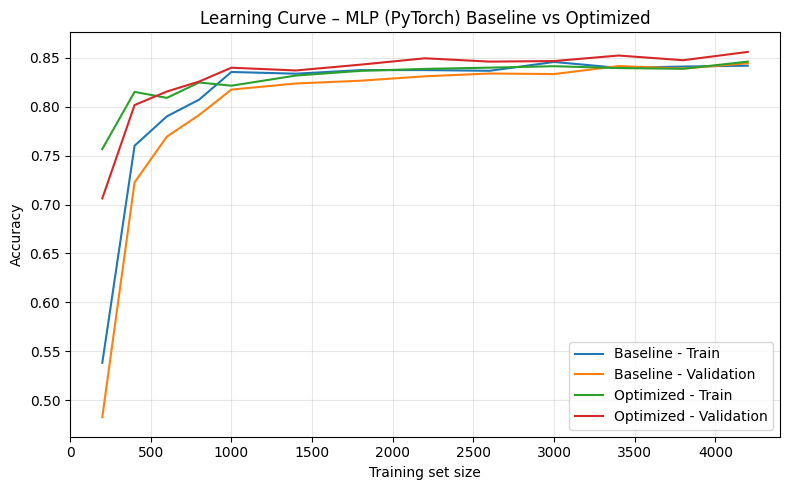

In [73]:
# ===== Dataset class (như bạn đang dùng) =====
class FaultDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def run_learning_curve(cfg, X_train_raw, y_train_int, X_val_raw, y_val_int,
                       train_sizes, n_repeats=3, epochs=60, batch_size=64, device=None):
    """
    cfg: dict giống baseline_cfg / best_cfg (có hidden_dims, dropout, lr, weight_decay)
    X_train_raw, X_val_raw: dữ liệu CHƯA scale (float32)
    y_train_int, y_val_int: nhãn int (0..C-1)
    """
    rng = np.random.RandomState(42)

    train_scores = []
    val_scores = []

    for s in train_sizes:
        tr_accs = []
        va_accs = []

        for r in range(n_repeats):
            # lấy subset stratified theo y_train
            X_sub, _, y_sub, _ = train_test_split(
                X_train_raw, y_train_int,
                train_size=s,
                random_state=int(rng.randint(0, 10**9)),
                stratify=y_train_int
            )

            # scaler fit trên subset train, transform subset & val (tránh leakage)
            scaler = StandardScaler()
            X_sub_sc = scaler.fit_transform(X_sub).astype(np.float32)
            X_val_sc = scaler.transform(X_val_raw).astype(np.float32)

            sub_loader = DataLoader(FaultDataset(X_sub_sc, y_sub), batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(FaultDataset(X_val_sc, y_val_int), batch_size=batch_size, shuffle=False)

            in_dim = X_sub_sc.shape[1]
            out_dim = len(np.unique(np.concatenate([y_train_int, y_val_int])))

            model = MLP(in_dim, cfg["hidden_dims"], out_dim, dropout=cfg["dropout"]).to(device)
            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(
                model.parameters(),
                lr=cfg["lr"],
                weight_decay=cfg.get("weight_decay", 0.0)
            )

            best_va = -1.0
            best_tr = -1.0

            for ep in range(epochs):
                _, tr_acc = train_one_epoch(model, sub_loader, criterion, optimizer, device)
                _, va_acc, _, _ = evaluate(model, val_loader, criterion, device)

                if va_acc > best_va:
                    best_va = va_acc
                    best_tr = tr_acc

            tr_accs.append(best_tr)
            va_accs.append(best_va)

        train_scores.append(float(np.mean(tr_accs)))
        val_scores.append(float(np.mean(va_accs)))

    return train_scores, val_scores


# ====== CHỌN train_sizes tự động theo size train hiện tại ======
# (tự cắt để không vượt quá len(X_train))
train_sizes = [200, 400, 600, 800, 1000, 1400, 1800, 2200, 2600, 3000, 3400, 3800, 4200]
train_sizes = [s for s in train_sizes if s <= len(X_train)]
print("train_sizes:", train_sizes)

# ====== Baseline curve ======
base_tr_curve, base_val_curve = run_learning_curve(
    baseline_cfg, X_train.astype(np.float32), y_train, X_val.astype(np.float32), y_val,
    train_sizes=train_sizes, n_repeats=3, epochs=60, batch_size=64, device=device
)

# ====== Optimized curve ======
# best_cfg là cfg0 (không có epochs/patience/verbose) -> thêm lr/weight_decay nếu thiếu
opt_cfg = {
    "hidden_dims": best_cfg["hidden_dims"],
    "dropout": best_cfg["dropout"],
    "lr": best_cfg.get("lr", 1e-3),
    "weight_decay": best_cfg.get("weight_decay", 0.0),
}

opt_tr_curve, opt_val_curve = run_learning_curve(
    opt_cfg, X_train.astype(np.float32), y_train, X_val.astype(np.float32), y_val,
    train_sizes=train_sizes, n_repeats=3, epochs=60, batch_size=64, device=device
)

# ====== Vẽ (4 đường) ======
plt.figure(figsize=(8,5))
plt.plot(train_sizes, base_tr_curve, label="Baseline - Train")
plt.plot(train_sizes, base_val_curve, label="Baseline - Validation")
plt.plot(train_sizes, opt_tr_curve,  label="Optimized - Train")
plt.plot(train_sizes, opt_val_curve, label="Optimized - Validation")

plt.title("Learning Curve – MLP (PyTorch) Baseline vs Optimized")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
y_min = min(base_tr_curve + base_val_curve + opt_tr_curve + opt_val_curve) - 0.02
y_max = max(base_tr_curve + base_val_curve + opt_tr_curve + opt_val_curve) + 0.02
plt.ylim(y_min, y_max)
plt.show()